## Lending Club Investor Loan Risk Selector - Exploratory Data Analysis

---

### **Executive Summary**

This notebook performs exploratory data analysis on the Lending Club accepted-loan dataset to support an **investor-style loan risk selector**.

The business goal is not to approve or reject borrowers on behalf of a bank. The goal is to help an investor review LendingClub loan listings and identify loans with elevated risk before deciding whether to invest.

**Key Findings to Validate in EDA:**
- The dataset contains borrower, loan listing, credit bureau, and post-loan performance fields.
- The modeling target should use only loans with clear observed outcomes.
- `Fully Paid` is treated as non-default, while `Charged Off`, `Default`, and `Late (31-120 days)` are treated as serious delinquency/default-like outcomes.
- `Current`, `In Grace Period`, and `Late (16-30 days)` are excluded because their final outcome is uncertain.
- LendingClub-assigned fields such as `grade`, `sub_grade`, and `int_rate` are allowed for this investor-style use case because they are visible on the loan listing before investment.
- Post-loan payment, recovery, hardship, settlement, and last-credit-pull fields must be removed because they reveal information created after the investment decision.
- Some credit bureau tradeline fields are schema-driven missingness: they are mostly unavailable in older vintages and mostly available after 2015.

**Business Impact:**
The final model should rank listed loans by predicted risk so investors can avoid the highest-risk loans, compare risk bands, and evaluate portfolio-level tradeoffs.


---
### **Objective**

Before building a machine learning model, this notebook explores the dataset structure, data quality, target definition, leakage risk, temporal drift, and feature behavior.

**In this notebook, I perform EDA to:**
- Understand the structure and size of the LendingClub accepted-loan dataset.
- Define a clean binary target for serious delinquency/default-like risk.
- Identify missing values and distinguish informative missingness from schema-driven missingness.
- Detect and flag data leakage features created after the loan was issued.
- Analyze relationships between investor-visible listing features and default risk.
- Identify temporal drift and feature-availability drift across loan vintages.
- Identify feature engineering opportunities for the next notebook.

**At this stage, I am NOT:**
- Making final model-selection decisions.
- Permanently transforming raw data for modeling.
- Training production models.

This notebook remains **exploratory and mostly non-destructive**, except for creating temporary columns needed for analysis such as `target` and `issue_year`.


### SETUP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 10

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Numpy version: 1.26.4
Pandas version: 2.2.2


### Data Loading

In [2]:
# Setup paths using relative path (cross-platform compatible)
# This ensures the notebook works on any machine

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))


# Define data path
DATA_PATH = os.path.join(project_root, 'src', 'data', 'raw', 'accepted_2007_to_2018Q4.csv')

print(f"Project root: {project_root}")

print(f"Data Path: {DATA_PATH}")

print(f"Path Exists: {os.path.exists(DATA_PATH)}")


Project root: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML
Data Path: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\data\raw\accepted_2007_to_2018Q4.csv
Path Exists: True


---
### Sampling Strategy

The full LendingClub accepted-loan dataset contains more than 2.26 million
rows and 152 features. Loading the entire dataset for EDA is computationally
expensive and unnecessary at the exploration stage.

A sample of **500,000 loans (~22% of the full dataset)** is used here for
initial exploration.

**Sampling method:** The CSV is read in chunks of 50,000 rows, and 22% of
each chunk is randomly sampled. Since LendingClub data is broadly
chronological, sampling proportionally from every chunk across the file
ensures all years from 2007 to 2018 are represented in proportion to their
actual share of the dataset — avoiding the bias of a sequential
`nrows=500_000` load, which would only capture early loan vintages.
This matches the platform's real growth trajectory — loan volume increased
significantly after 2013, and the sample reflects this proportionally.

Because of this, the notebook includes year-wise checks for:
- loan volume by issue year
- default rate by issue year
- missingness by issue year

In [3]:
print(os.getcwd())

C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\notebooks


In [4]:
sys.path.append(project_root)
from src.data.load_data import load_dataset

In [5]:
# Load sample dataset for EDA
# SAMPLE_FRAC = 500_000 / 2_260_701 = 0.221
# Using 500K rows to balance memory efficiency with statistical power

import pandas as pd
import gc

CSV_CHUNK_SIZE = 50_000
SAMPLE_FRAC    = 0.221   # ~500K rows from 2.26M
RANDOM_STATE   = 42

sampled_chunks = []

for i, chunk in enumerate(
    pd.read_csv(DATA_PATH, chunksize=CSV_CHUNK_SIZE, low_memory=False)
):
    sampled = chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    sampled_chunks.append(sampled)
    
    if i % 10 == 0:
        print(f"Chunk {i} processed")
    
    del chunk
    gc.collect()

df = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks
gc.collect()

Chunk 0 processed
Chunk 10 processed
Chunk 20 processed
Chunk 30 processed
Chunk 40 processed


0

In [6]:
# verify temporal coverage
df['issue_d']    = pd.to_datetime(df['issue_d'], errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

print(df['issue_year'].value_counts().sort_index())
print(f"\nLoaded {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

issue_year
2007.0       145
2008.0       527
2009.0      1191
2010.0      2705
2011.0      4852
2012.0     11799
2013.0     29834
2014.0     52064
2015.0     93112
2016.0     95915
2017.0     98080
2018.0    109384
Name: count, dtype: int64

Loaded 499615 rows and 152 columns
Memory Usage: 1298.00 MB


In [7]:
import psutil
ram = psutil.virtual_memory()
print(f"Available RAM : {ram.available / 1e9:.2f} GB")

Available RAM : 2.30 GB


In [8]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,issue_year
0,66420561,NaN,6000.0,6000.0,6000.0,36 months,7.26,185.98,A,A4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2015.0
1,67939078,NaN,12575.0,12575.0,12425.0,60 months,18.49,322.69,E,E2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2015.0
2,68366850,NaN,16000.0,16000.0,16000.0,36 months,5.32,481.84,A,A1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2015.0
3,67315303,NaN,21150.0,21150.0,21150.0,60 months,13.67,488.52,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2015.0
4,66025598,NaN,6000.0,6000.0,6000.0,36 months,5.32,180.69,A,A1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2015.0


In [9]:
df.shape

(499615, 152)

In [10]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term,issue_year
count,0.0,499608.000000,499608.000000,499608.000000,499608.000000,499608.000000,4.996070e+05,499608,499241.000000,499603.000000,...,2390.000000,2390.0,2390.000000,1884.000000,2390.000000,2390.000000,7660.000000,7660.000000,7660.000000,499608.000000
mean,NaN,15038.937727,15034.108491,15015.321040,13.101114,445.425962,7.798516e+04,2016-05-02 12:52:58.210116864,18.822498,0.306361,...,152.151900,3.0,13.716318,440.981226,11568.596050,192.391891,4969.237692,47.835948,13.295170,2015.857012
min,NaN,500.000000,500.000000,0.000000,5.310000,15.670000,0.000000e+00,2007-06-01 00:00:00,0.000000,0.000000,...,1.610000,3.0,0.000000,6.450000,191.120000,0.010000,121.910000,19.760000,0.000000,2007.000000
25%,NaN,8000.000000,8000.000000,8000.000000,9.490000,251.400000,4.600000e+04,2015-04-01 00:00:00,11.880000,0.000000,...,56.822500,3.0,5.000000,166.680000,5544.705000,43.405000,2219.037500,45.000000,6.000000,2015.000000
50%,NaN,12800.000000,12800.000000,12800.000000,12.620000,377.510000,6.500000e+04,2016-07-01 00:00:00,17.830000,0.000000,...,117.840000,3.0,15.000000,342.705000,9904.285000,130.385000,4135.935000,45.000000,14.000000,2016.000000
75%,NaN,20000.000000,20000.000000,20000.000000,15.990000,592.430000,9.300000e+04,2017-11-01 00:00:00,24.490000,0.000000,...,214.747500,3.0,22.000000,597.690000,16093.132500,281.845000,6800.725000,50.000000,18.000000,2017.000000
max,NaN,40000.000000,40000.000000,40000.000000,30.990000,1719.830000,8.900060e+06,2018-12-01 00:00:00,999.000000,28.000000,...,837.680000,3.0,32.000000,2513.040000,38390.380000,1291.210000,30000.000000,184.360000,65.000000,2018.000000
std,NaN,9196.933748,9195.099544,9199.324601,4.838090,267.181753,7.610964e+04,NaN,14.649856,0.861281,...,125.654141,0.0,9.673741,365.435925,7623.870109,197.735109,3633.439218,6.921352,8.073575,1.793229


In [11]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_last_payment_amount', 'disbursement_method',
       'debt_settlement_flag', 'debt_settlement_flag_date',
       'settlement_status', 'settlement_date', 'settlement_amount',
       'settlement_percentage', 'settlement_term', 'issue_year'],
      dtype='object', length=152)

In [12]:
# Data types distribution

dtype_counts = df.dtypes.value_counts()

print("Data Type Distribution:")
print(dtype_counts)

print()

print(f" - Numerical (int/float): {len(df.select_dtypes(include=['int', 'float']).columns)} features")
print(f" - Categorical : {len(df.select_dtypes(include=['object', 'category']).columns)} features")

Data Type Distribution:
float64           114
object             37
datetime64[ns]      1
Name: count, dtype: int64

 - Numerical (int/float): 114 features
 - Categorical : 37 features


In [13]:
# Check for duplicate rows

duplicates = df.duplicated().sum()
# print(duplicates)

print(f" Duplicate rows : {duplicates:,} ({duplicates / len(df) * 100:.2f} %)")
if duplicates > 0:
     print(" Warning: Duplicates found. Will handle in feature engineering.")
else:
    print(" No duplicate rows detected")

 Duplicate rows : 0 (0.00 %)
 No duplicate rows detected


---
###  Missing Values 

In credit data, missing values often carry business meaning:
- No delinquency history → borrower never defaulted
- No hardship info → borrower never filed for hardship
- Missing employment data → borrower chose not to disclose

Therefore, missing values are **NOT blindly dropped** at this stage.

---

In [14]:
# missing value analysis

missing_summary = pd.DataFrame({
    'features' : df.columns,
    'missing_count' : df.isna().sum().values,
    'missing_percentage' : (df.isna().mean() * 100).round(2).values,
    'dtype' : df.dtypes.values
}).sort_values('missing_percentage', ascending = False)

missing_summary = missing_summary[missing_summary['missing_count'] > 0]

print(f"Total columns with missing values: {len(missing_summary)}")
print(f"Total columns with no missing values: {df.shape[1] - len(missing_summary)}")
print()
print(missing_summary.head(20))

Total columns with missing values: 151
Total columns with no missing values: 1

                                       features  missing_count  \
1                                     member_id         499615   
140  orig_projected_additional_accrued_interest         497731   
129                               hardship_type         497225   
141              hardship_payoff_balance_amount         497225   
130                             hardship_reason         497225   
131                             hardship_status         497225   
132                               deferral_term         497225   
133                             hardship_amount         497225   
134                         hardship_start_date         497225   
135                           hardship_end_date         497225   
136                     payment_plan_start_date         497225   
137                             hardship_length         497225   
139                        hardship_loan_status         497225

In [15]:
# Summary statistics

high_missing = (missing_summary['missing_percentage'] > 70).sum()
medium_missing = ((missing_summary['missing_percentage'] > 30) & (missing_summary['missing_percentage'] <= 70)).sum()
low_missing = ((missing_summary['missing_percentage'] > 0) & (missing_summary['missing_percentage'] <= 30)).sum()
no_missing = (missing_summary['missing_percentage'] == 0).sum()

print(f"\n Missing Value Summary:")
print(f"  High (>70%): {high_missing} features")
print(f"  Medium (30-70%): {medium_missing} features")
print(f"  Low (<30%): {low_missing} features")
print(f"  Complete (0%): {no_missing} features")


 Missing Value Summary:
  High (>70%): 41 features
  Medium (30-70%): 17 features
  Low (<30%): 44 features
  Complete (0%): 49 features


### Visualize missing value patterns

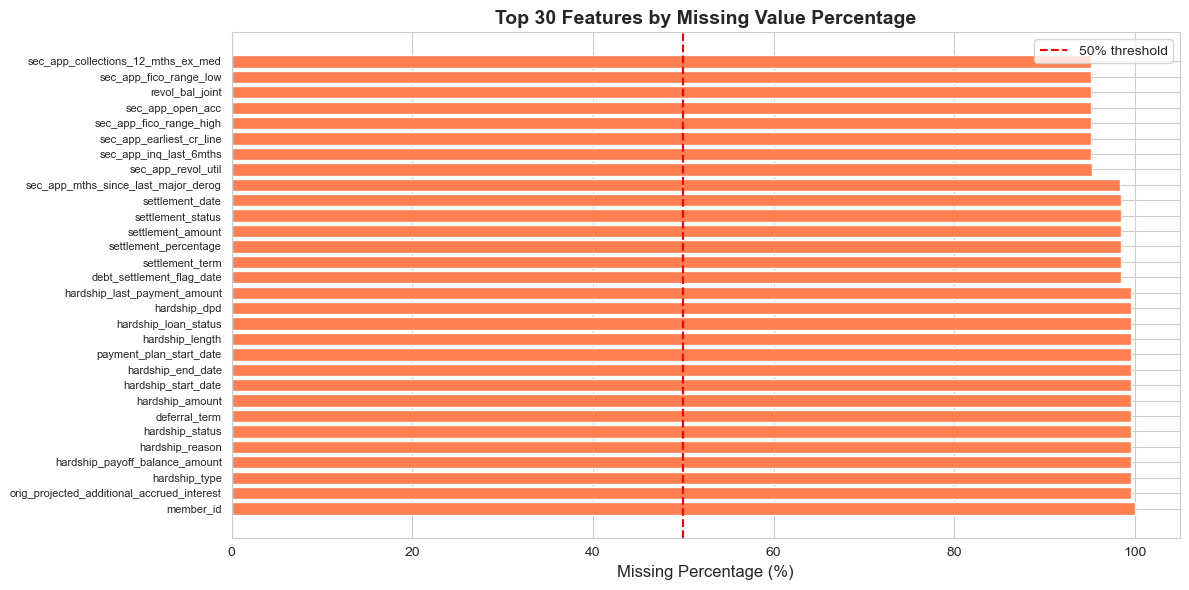

In [16]:
plt.figure(figsize = (12, 6))
top_missing = missing_summary.head(30)
plt.barh(range(len(top_missing)),top_missing['missing_percentage'], color = 'coral')
plt.yticks(range(len(top_missing)), top_missing['features'], fontsize=8)
plt.xlabel('Missing Percentage (%)', fontsize = 12)
plt.title('Top 30 Features by Missing Value Percentage', fontsize=14, weight='bold')
plt.axvline(x = 50, color = 'red', linestyle = '--', label = '50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
informative_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq',
    'mths_since_last_major_derog',
    'bc_util',
]

print("Informative Missingness Columns:")
print(missing_summary[missing_summary['features'].isin(informative_cols)])

Informative Missingness Columns:
                          features  missing_count  missing_percentage    dtype
31          mths_since_last_record         420300               84.12  float64
90        mths_since_recent_bc_dlq         384663               76.99  float64
54     mths_since_last_major_derog         371454               74.35  float64
92  mths_since_recent_revol_delinq         336123               67.28  float64
30          mths_since_last_delinq         256508               51.34  float64
69                         il_util         236358               47.31  float64
67              mths_since_rcnt_il         201299               40.29  float64
11                      emp_length          32630                6.53   object
81                         bc_util          16796                3.36  float64


### Missing Value Analysis
---
#### Columns Retained Despite High Missingness

Not all missing values represent bad data.
In credit risk, a missing value often carries a meaning of its own.

For the columns above, **missingness is informative** —
the absence of a value tells us something about the borrower's
credit history that is just as useful as the value itself.

These columns will be retained and handled appropriately
in the Feature Engineering notebook.

---

#### Why Missingness Carries Signal Here

In credit bureau data, fields like "months since last delinquency"
are only populated when a delinquency actually occurred.
If the field is blank, it means the borrower has **never** had that
negative event on their record — which is a positive credit signal.

Removing these columns would discard that information entirely.
Instead, we will engineer a binary flag to capture this signal
before imputing the remaining values.

---

> **Key principle:** Missing value treatment is not always about
> filling gaps. In credit risk specifically, understanding *why*
> a value is missing is as important as the value itself.
> A borrower with no delinquency history is fundamentally different
> from a borrower whose delinquency data was simply not recorded.

---

#### Columns with Informative Missingness

| Column | Missing % | What Missing Means | How It Will Be Used |
|---|---|---|---|
| `mths_since_last_record` | 84.12% | No public record (bankruptcy, judgment, lien) | Create `has_public_record` flag (1/0), then impute |
| `mths_since_recent_bc_dlq` | 76.99% | No bankcard delinquency on record | Create binary flag, then impute |
| `mths_since_last_major_derog` | 74.35% | No major derogatory mark ever recorded | Create binary flag, then impute |
| `mths_since_recent_revol_delinq` | 67.28% | No revolving account delinquency | Create binary flag, then impute |
| `mths_since_last_delinq` | 51.34% | Borrower has never been delinquent | Create `ever_delinquent` flag (1/0), then impute |

---



### Feature Categorization

To better understand the dataset, I categorize features by type and business purpose.

In [18]:
# Separate numerical and categorical columns

num_col = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
cat_col = df.select_dtypes(include = ['object']).columns.tolist()

print(f" Numerical features: {len(num_col)}")
print(f" Categorical features : {len(cat_col)}")

 Numerical features: 114
 Categorical features : 37


In [19]:
# Identify date columns
possible_date_cols = [
    col for col in cat_col
    if any(keyword in col.lower() for keyword in ['_d','date','time','mths'])
]

print(f" Possible Date columns ({len(possible_date_cols)}):")
for col in possible_date_cols:
    print(f" - {col}")

 Possible Date columns (8):
 - last_pymnt_d
 - next_pymnt_d
 - last_credit_pull_d
 - hardship_start_date
 - hardship_end_date
 - payment_plan_start_date
 - debt_settlement_flag_date
 - settlement_date


#### A. Personal / Borrower Details

| Column Name | Feature Understanding | Business Reasoning |
|------------|----------------------|-------------------|
| emp_length | Years of employment | Longer employment → stable income → lower default risk |
| emp_title | Job title | Certain professions are more financially stable |
| home_ownership | Housing status (Rent/Own/Mortgage) | Renters generally show higher default risk |
| annual_inc | Annual income reported | Higher income → better repayment capacity |
| verification_status | Income verification status | Verified borrowers show higher default rates — LC verifies applicants who appear risky, making this a marker of suspicion rather than safety |
| addr_state | State of residence | Regional economic factors affect default |
| zip_code | ZIP code (first 3 digits) | Local economic conditions matter |

#### B. Loan Characteristics / Investor-Visible Listing Features

| Column Name | Feature Understanding | Business Reasoning |
|------------|----------------------|-------------------|
| loan_amnt | Loan amount requested | Higher loans may increase repayment pressure. |
| funded_amnt | Amount funded | Highly redundant with `loan_amnt`; may be dropped later. |
| int_rate | LendingClub-assigned interest rate | Allowed in investor-style modeling because investors see it before investing; also reflects LendingClub's risk pricing. |
| installment | Monthly payment | High payment burden can increase default risk, but it is also mathematically related to loan amount, rate, and term. |
| term | Loan duration: 36 or 60 months | Longer terms usually carry higher default risk. |
| grade | LendingClub risk grade | Allowed for investor-style analysis; redundant with `sub_grade`. |
| sub_grade | Fine-grained LendingClub risk grade | Strong investor-visible risk segmentation feature. |
| purpose | Purpose of loan | Some purposes default more often, such as small business or debt consolidation. |


#### C. Credit History Features

| Column Name | Feature Understanding | Business Reasoning |
|------------|----------------------|-------------------|
| dti | Debt-to-income ratio | Higher debt burden → higher default risk |
| fico_range_low | Lower bound of FICO score | Credit score is the strongest default predictor |
| fico_range_high | Upper bound of FICO score | Range indicates credit quality |
| earliest_cr_line | Date credit history started | Longer history → more established borrower |
| open_acc | Number of open credit lines | Too many or too few can be risky |
| total_acc | Total number of credit lines | Indicates credit experience |
| revol_bal | Total revolving balance | High balances indicate financial stress |
| revol_util | Revolving utilization rate | High utilization → credit stress |
| delinq_2yrs | Delinquencies in past 2 years | Past behavior predicts future behavior |
| pub_rec | Public records (bankruptcies) | Clear negative indicator |

### Target Variable

In [20]:
loan_status = df['loan_status'].value_counts().sort_values(ascending = False)
loan_status

loan_status
Fully Paid                                             238047
Current                                                193934
Charged Off                                             59473
Late (31-120 days)                                       4653
In Grace Period                                          1884
Late (16-30 days)                                         970
Does not meet the credit policy. Status:Fully Paid        464
Does not meet the credit policy. Status:Charged Off       174
Default                                                     9
Name: count, dtype: int64

### Target Variable Definition

#### What We Are Predicting

For this investor-style LendingClub project, the model predicts whether a listed loan is likely to become a **serious delinquency/default-like risk** after investment.

The model may use fields that are visible to investors at listing time, including LendingClub-assigned risk/pricing fields such as `grade`, `sub_grade`, and `int_rate`. It must not use fields created after loan performance begins, such as payments, recoveries, settlements, hardship activity, or last FICO updates.

We train only on loans where the outcome is clear enough to label.

---

#### How We Define the Target

| Loan Status | Label | Reason |
|---|---:|---|
| `Fully Paid` | 0 | Loan completed successfully. |
| `Charged Off` | 1 | Lender wrote off the debt after severe non-payment. |
| `Default` | 1 | Explicit default status. |
| `Late (31-120 days)` | 1 | Serious delinquency/default-like risk. Some loans may cure, but this is already a materially risky state. |
| `Current` | Excluded | Active loan with unknown final outcome; treating it as non-default would create right-censoring bias. |
| `In Grace Period` | Excluded | Early missed-payment state, usually 1-15 days late; too uncertain to label cleanly. |
| `Late (16-30 days)` | Excluded | Early delinquency; many borrowers may self-cure, so labeling as default or non-default would add noise. |

---

In [21]:
def classify_loan_status(status):
    """
    Convert LendingClub loan_status into a binary investor-risk target.

    Returns:
        0 = Fully paid loan
        1 = Serious delinquency/default-like outcome
        None = uncertain or still-active outcome, excluded from modeling
    """
    non_default = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

    default_like = [
        'Charged Off',
        'Default',
        'Late (31-120 days)',
        'Does not meet the credit policy. Status:Charged Off'
    ]

    if status in non_default:
        return 0
    elif status in default_like:
        return 1
    else:
        return None

# Create temporary EDA target.
df['target'] = df['loan_status'].apply(classify_loan_status)
df['target']


0         0.0
1         NaN
2         0.0
3         NaN
4         0.0
         ... 
499610    0.0
499611    NaN
499612    0.0
499613    NaN
499614    NaN
Name: target, Length: 499615, dtype: float64

In [22]:
# Count excluded rows (expected)

excluded_count = df['target'].isna().sum()
print(f"Excluded loans (no final outcome): {excluded_count}")

# Now check for truly unexpected values
expected_status = [
    'Fully Paid', 'Charged Off', 'Default',
    'Late (31-120 days)', 'Current',
    'In Grace Period', 'Late (16-30 days)',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]

unexpected = df.loc[~df['loan_status'].isin(expected_status), 'loan_status'].unique()

if len(unexpected) > 0:
    print(" Unexpected loan statuses found:", unexpected)
else:
    print(" All loan statuses are expected")

Excluded loans (no final outcome): 196795
 Unexpected loan statuses found: [nan]


In [23]:
print(f"Rows with missing loan_status: {df['loan_status'].isna().sum()}")
print(df[df[['loan_status']].isna()].head())

Rows with missing loan_status: 7
    id  member_id  loan_amnt  funded_amnt  funded_amnt_inv term  int_rate  \
0  NaN        NaN        NaN          NaN              NaN  NaN       NaN   
1  NaN        NaN        NaN          NaN              NaN  NaN       NaN   
2  NaN        NaN        NaN          NaN              NaN  NaN       NaN   
3  NaN        NaN        NaN          NaN              NaN  NaN       NaN   
4  NaN        NaN        NaN          NaN              NaN  NaN       NaN   

   installment grade sub_grade  ... disbursement_method debt_settlement_flag  \
0          NaN   NaN       NaN  ...                 NaN                  NaN   
1          NaN   NaN       NaN  ...                 NaN                  NaN   
2          NaN   NaN       NaN  ...                 NaN                  NaN   
3          NaN   NaN       NaN  ...                 NaN                  NaN   
4          NaN   NaN       NaN  ...                 NaN                  NaN   

  debt_settlement_flag_

In [24]:
remaining_missing = df[df['loan_status'].isna()]
print(remaining_missing[['loan_status']])

       loan_status
94345          NaN
111272         NaN
115710         NaN
193526         NaN
429343         NaN
498118         NaN
499111         NaN


> **Data quality note:** 7 rows had a completely missing `loan_status`
> value (likely malformed rows in the source CSV). These were
> automatically excluded by the `classify_loan_status` function

In [25]:
# Drop all rows where loan_status is missing (footer/garbage rows)
df = df[df['loan_status'].notna()]

print(f"Rows after dropping footer rows: {len(df):,}")
print(f"loan_status missing now: {df['loan_status'].isna().sum()}")

Rows after dropping footer rows: 499,608
loan_status missing now: 0


In [26]:
print(df['target'].value_counts(dropna=False))
print()
print(df['target'].value_counts(normalize=True, dropna=False).round(4) * 100)

target
0.0    238511
NaN    196788
1.0     64309
Name: count, dtype: int64

target
0.0    47.74
NaN    39.39
1.0    12.87
Name: proportion, dtype: float64


In [27]:
# target distribution

target_dist = df['target'].value_counts()
target_dist_pct = df['target'].value_counts(normalize  = True) * 100

print(target_dist)
print(f"\n Percentages:")
print(f" 0(Non- Default): {target_dist_pct[0]:.2f}%")
print(f" 1( Default): {target_dist_pct[1]:.2f}%")

target
0.0    238511
1.0     64309
Name: count, dtype: int64

 Percentages:
 0(Non- Default): 78.76%
 1( Default): 21.24%


In [28]:
# Calculate imbalance ratio
imbalance_ratio = target_dist[0] / target_dist[1]
print(imbalance_ratio)

3.708827691302928


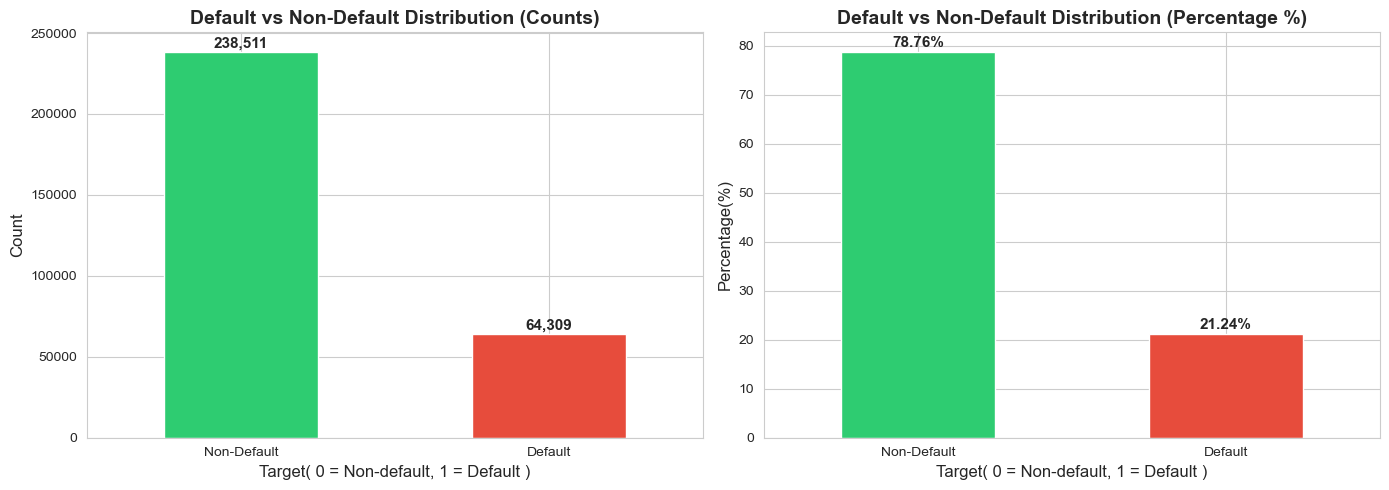

In [29]:
# Visualize target distribution

fig, (ax1,ax2) = plt.subplots(1, 2, figsize = (14,5))

# Count Plot 
target_dist.plot(kind = 'bar',ax = ax1,color = ['#2ecc71', '#e74c3c'])
ax1.set_title('Default vs Non-Default Distribution (Counts)', fontsize = 14, weight = 'bold')
ax1.set_xlabel('Target( 0 = Non-default, 1 = Default )', fontsize = 12)
ax1.set_ylabel('Count', fontsize = 12)
ax1.set_xticklabels(['Non-Default','Default'], rotation = 0)

offset = max(target_dist) * 0.01  # 1% of max value
for i,v in enumerate(target_dist):
    ax1.text(i, v+offset ,f'{v:,}', ha = 'center',fontsize = 11, weight = 'bold')

# Percentage Plot 
target_dist_pct.plot(kind = 'bar',ax = ax2,color = ['#2ecc71', '#e74c3c'])
ax2.set_title('Default vs Non-Default Distribution (Percentage %)', fontsize = 14, weight = 'bold')
ax2.set_xlabel('Target( 0 = Non-default, 1 = Default )', fontsize = 12)
ax2.set_ylabel('Percentage(%)', fontsize = 12)
ax2.set_xticklabels(['Non-Default','Default'], rotation = 0)

for i,v in enumerate(target_dist_pct):
    ax2.text(i, v+1,f'{v:.2f}%', ha = 'center',fontsize = 11, weight = 'bold')


plt.tight_layout()
plt.show()

---
### Temporal and Schema Drift Analysis

Because LendingClub data spans many years, model performance can be affected by changes in borrower mix, macroeconomic conditions, underwriting policy, and dataset schema.

This section checks whether default risk and feature availability change by `issue_year`.

This is especially important for bureau tradeline fields such as `open_acc_6m`, `open_rv_12m`, `inq_fi`, and `all_util`, which are mostly missing in older years and mostly populated after 2015. That pattern is not ordinary borrower-level missingness; it is **schema-driven missingness**.


In [30]:
# Create issue year for temporal EDA.
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

issue_year_summary = (
    df.groupby('issue_year')
      .agg(
          loan_count=('target', 'size'),
          default_like_rate=('target', 'mean')
      )
      .reset_index()
)

issue_year_summary['default_like_rate'] = (issue_year_summary['default_like_rate'] * 100).round(2)
issue_year_summary


,issue_year,loan_count,default_like_rate
0,2007,145,27.59
1,2008,527,21.25
2,2009,1191,15.37
3,2010,2705,14.12
4,2011,4852,15.19
5,2012,11799,16.76
6,2013,29834,15.69
7,2014,52064,18.44
8,2015,93112,20.44
9,2016,95915,24.42


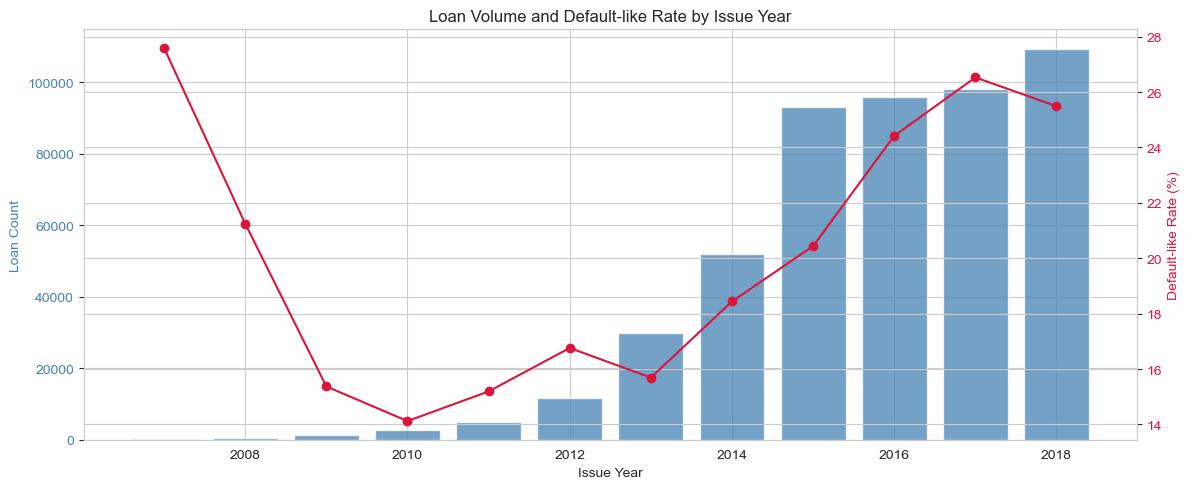

In [31]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(issue_year_summary['issue_year'], issue_year_summary['loan_count'], color='steelblue', alpha=0.75)
ax1.set_xlabel('Issue Year')
ax1.set_ylabel('Loan Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(issue_year_summary['issue_year'], issue_year_summary['default_like_rate'], color='crimson', marker='o')
ax2.set_ylabel('Default-like Rate (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Loan Volume and Default-like Rate by Issue Year')
fig.tight_layout()
plt.show()


In [32]:
# Discover columns where missingness changed dramatically over time
numeric_cols = df.select_dtypes(include=['float32', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['target', 'issue_year']]

pre_2015  = df[df['issue_year'] < 2015]
post_2015 = df[df['issue_year'] >= 2015]

drift_summary = pd.DataFrame({
    'missing_pre_2015'  : pre_2015[numeric_cols].isna().mean() * 100,
    'missing_post_2015' : post_2015[numeric_cols].isna().mean() * 100,
})

drift_summary['difference'] = (
    drift_summary['missing_pre_2015'] - drift_summary['missing_post_2015']
)

drift_summary = drift_summary.sort_values('difference', ascending=False)
drift_summary.round(2).head(15)

,missing_pre_2015,missing_post_2015,difference
open_rv_24m,100.00,22.29,77.71
inq_last_12m,100.00,22.29,77.71
max_bal_bc,100.00,22.29,77.71
inq_fi,100.00,22.29,77.71
open_acc_6m,100.00,22.29,77.71
open_act_il,100.00,22.29,77.71
open_il_12m,100.00,22.29,77.71
open_il_24m,100.00,22.29,77.71
open_rv_12m,100.00,22.29,77.71
total_bal_il,100.00,22.29,77.71


In [33]:
# Use columns where difference > 30% as confirmed schema-drift columns
schema_drift_cols = drift_summary[drift_summary['difference'] > 30].index.tolist()

print(f"Schema drift columns discovered ({len(schema_drift_cols)}):")
print(schema_drift_cols)

tradeline_availability_by_year = (
    df.groupby('issue_year')[schema_drift_cols]
      .apply(lambda x: x.notna().mean() * 100)
      .round(2)
)
tradeline_availability_by_year

Schema drift columns discovered (14):
['open_rv_24m', 'inq_last_12m', 'max_bal_bc', 'inq_fi', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'total_bal_il', 'total_cu_tl', 'all_util', 'mths_since_rcnt_il', 'il_util']


,open_rv_24m,inq_last_12m,max_bal_bc,inq_fi,open_acc_6m,open_act_il,open_il_12m,open_il_24m,open_rv_12m,total_bal_il,total_cu_tl,all_util,mths_since_rcnt_il,il_util
issue_year,,,,,,,,,,,,,,
2007,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2008,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2009,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2010,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2011,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2012,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2013,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2014,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2015,5.11,5.11,5.11,5.11,5.11,5.11,5.11,5.11,5.11,5.11,5.11,5.11,4.96,4.43



### Schema Drift — Credit Bureau Fields Introduced in 2015-2016

While checking missing values, `il_util` and `mths_since_rcnt_il`
showed unusually high overall missingness (~47% and ~40%). To
understand why, availability was compared by issue year across
14 related columns.

| Period | % of loans with data |
|---|---|
| 2007–2014 | 0% |
| 2015 | ~5% |
| 2016–2018 | 84–100% |

**Decision:** These 14 columns were dropped.

For loans from 2016 onward, the data is available and would carry
real signal. But for loans before 2016, the values are missing simply
because the field did not exist yet — not because of the borrower's
credit history. Since both types of missing values look the same in
the data, there is no clean way to separate them.

Handling this properly would mean treating pre-2016 and post-2016
loans differently, which adds complexity. Since `issue_year` already
captures loan vintage, these 14 columns were dropped in favor of
simpler, more interpretable features.


**Columns removed:**
open_rv_24m, inq_last_12m, max_bal_bc, inq_fi, open_acc_6m,
open_act_il, open_il_12m, open_il_24m, open_rv_12m, total_bal_il,
total_cu_tl, all_util, mths_since_rcnt_il, il_util

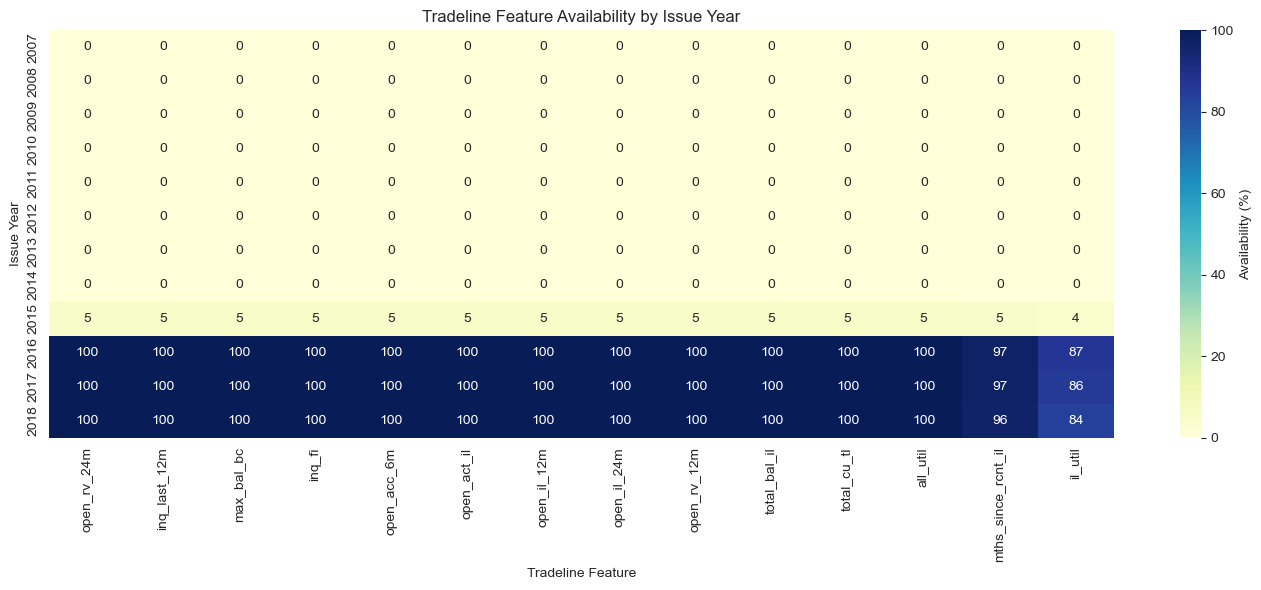

In [34]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    tradeline_availability_by_year,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Availability (%)'}
)
plt.title('Tradeline Feature Availability by Issue Year')
plt.xlabel('Tradeline Feature')
plt.ylabel('Issue Year')
plt.tight_layout()
plt.show()


In [ ]:
tradeline_data_cols = [
    'open_rv_24m', 'inq_last_12m', 'max_bal_bc', 'inq_fi',
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'open_rv_12m', 'total_bal_il', 'total_cu_tl', 'all_util',
    'mths_since_rcnt_il', 'il_util'
]

#### Data Leakage Detection

**What is data leakage?**
Information that would not be available to the investor at the time of loan-listing review.

For this investor-style project, investor-visible listing fields such as `grade`, `sub_grade`, and `int_rate` are allowed. However, any feature created after the loan is issued or after repayment begins is leakage.

**Examples of leakage:**
- post-loan payment amounts,
- outstanding principal after issue,
- recoveries and collection fees,
- settlement and hardship activity,
- last payment date,
- next payment date,
- last credit pull date,
- last FICO scores.

**Separate from leakage:**
Some fields are not leakage but are still excluded from v1 because they are sparse, optional, high-cardinality, or affected by schema changes across years.


### Data Leakage Categories

| Column Name | Why Leakage | Action |
|------------|------------|--------|
| loan_status | Final loan outcome | **Target variable only** |
| total_pymnt | Total payments made | Known only after repayment → Drop |
| total_pymnt_inv | Total paid to investors | Post-loan information → Drop |
| total_rec_prncp | Principal recovered | Known after payments → Drop |
| total_rec_int | Interest recovered | Known after payments → Drop |
| total_rec_late_fee | Late fees collected | Post-default information → Drop |
| recoveries | Amount recovered post-default | Only after default → Drop |
| collection_recovery_fee | Collection fees | Post-default → Drop |
| last_pymnt_amnt | Most recent payment amount | After loan issue → Drop |
| last_pymnt_d | Most recent payment date | After loan issue → Drop |
| next_pymnt_d | Next scheduled payment | Future information → Drop |
| last_credit_pull_d | Last credit check | After loan issue → Drop |

In [35]:
# Method 1: Keyword-based screening

leakage_keywords = [
    'last', 'next', 'total', 'recover',
    'pymnt', 'collection', 'fee',
    'settlement', 'chargeoff', 'paid', 'sec_app','hardship'
]

suspected_leakage = [
   col for col in df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print(f" Keyword - based leakage detection: {len(suspected_leakage)} features flagged")
print("\n Suspected leakage features:")
      
for col in sorted(suspected_leakage):
    print(f" - {col}")

 Keyword - based leakage detection: 59 features flagged

 Suspected leakage features:
 - chargeoff_within_12_mths
 - collection_recovery_fee
 - collections_12_mths_ex_med
 - debt_settlement_flag
 - debt_settlement_flag_date
 - hardship_amount
 - hardship_dpd
 - hardship_end_date
 - hardship_flag
 - hardship_last_payment_amount
 - hardship_length
 - hardship_loan_status
 - hardship_payoff_balance_amount
 - hardship_reason
 - hardship_start_date
 - hardship_status
 - hardship_type
 - inq_last_12m
 - inq_last_6mths
 - last_credit_pull_d
 - last_fico_range_high
 - last_fico_range_low
 - last_pymnt_amnt
 - last_pymnt_d
 - mths_since_last_delinq
 - mths_since_last_major_derog
 - mths_since_last_record
 - next_pymnt_d
 - pymnt_plan
 - recoveries
 - sec_app_chargeoff_within_12_mths
 - sec_app_collections_12_mths_ex_med
 - sec_app_earliest_cr_line
 - sec_app_fico_range_high
 - sec_app_fico_range_low
 - sec_app_inq_last_6mths
 - sec_app_mort_acc
 - sec_app_mths_since_last_major_derog
 - sec_app_

In [36]:
# Method 2: Correlation with target (high correlation = potential leakage)
# Features perfectly correlated with target are likely post-outcome

target_corr = (
    df.corr(numeric_only = True)['target']
    .abs()
    .sort_values(ascending = False)
    .drop('target') # Removes self-correlation
)

#print(target_corr.head(20))

# Flag features with suspiciously high correlation (>0.5)

high_corr_features = target_corr[target_corr > 0.5].index.tolist()
print(high_corr_features)
print(f"\n Features with high correlation > 0.5 : {len(high_corr_features)}")

['last_fico_range_high', 'last_fico_range_low']

 Features with high correlation > 0.5 : 2


In [37]:
# Combine leakage detection methods

all_leakage_candidates = list(set(suspected_leakage + high_corr_features))

print(f"\n Total Leakage candidates: {len(all_leakage_candidates)} features")

print(f"\n - These features will be removed during feature engineering.")
print(f"\n - For now, they remain in the dataset for exploratory purposes.")


 Total Leakage candidates: 59 features

 - These features will be removed during feature engineering.

 - For now, they remain in the dataset for exploratory purposes.


## Univariate Analysis - Numerical Features

Analyzing key numerical features and their relationship with default risk.

In [38]:
# Select important numerical features for analysis
# Based on domain knowledge and business relevance

key_num_features = [
    'annual_inc',
    'loan_amnt',
    'int_rate',
    'dti',
    'fico_range_low',
    'installment',
    'revol_util'
]

df[key_num_features].describe()

,annual_inc,loan_amnt,int_rate,dti,fico_range_low,installment,revol_util
count,4.996070e+05,499608.000000,499608.000000,499241.000000,499608.000000,499608.000000,499209.000000
mean,7.798516e+04,15038.937727,13.101114,18.822498,698.560101,445.425962,50.330507
std,7.610964e+04,9196.933748,4.838090,14.649856,32.977531,267.181753,24.698366
min,0.000000e+00,500.000000,5.310000,0.000000,610.000000,15.670000,0.000000
25%,4.600000e+04,8000.000000,9.490000,11.880000,675.000000,251.400000,31.500000
50%,6.500000e+04,12800.000000,12.620000,17.830000,690.000000,377.510000,50.300000
75%,9.300000e+04,20000.000000,15.990000,24.490000,715.000000,592.430000,69.300000
max,8.900060e+06,40000.000000,30.990000,999.000000,845.000000,1719.830000,177.700000


### Outlier Analysis

Several numerical features such as **annual_inc** and **dti** exhibit significant right skew and extreme values. These outliers appear to be genuine observations rather than data errors.

Instead of removing them, we plan to handle them during **feature engineering** using techniques such as **capping** and **log transformation** to reduce their impact on model training.

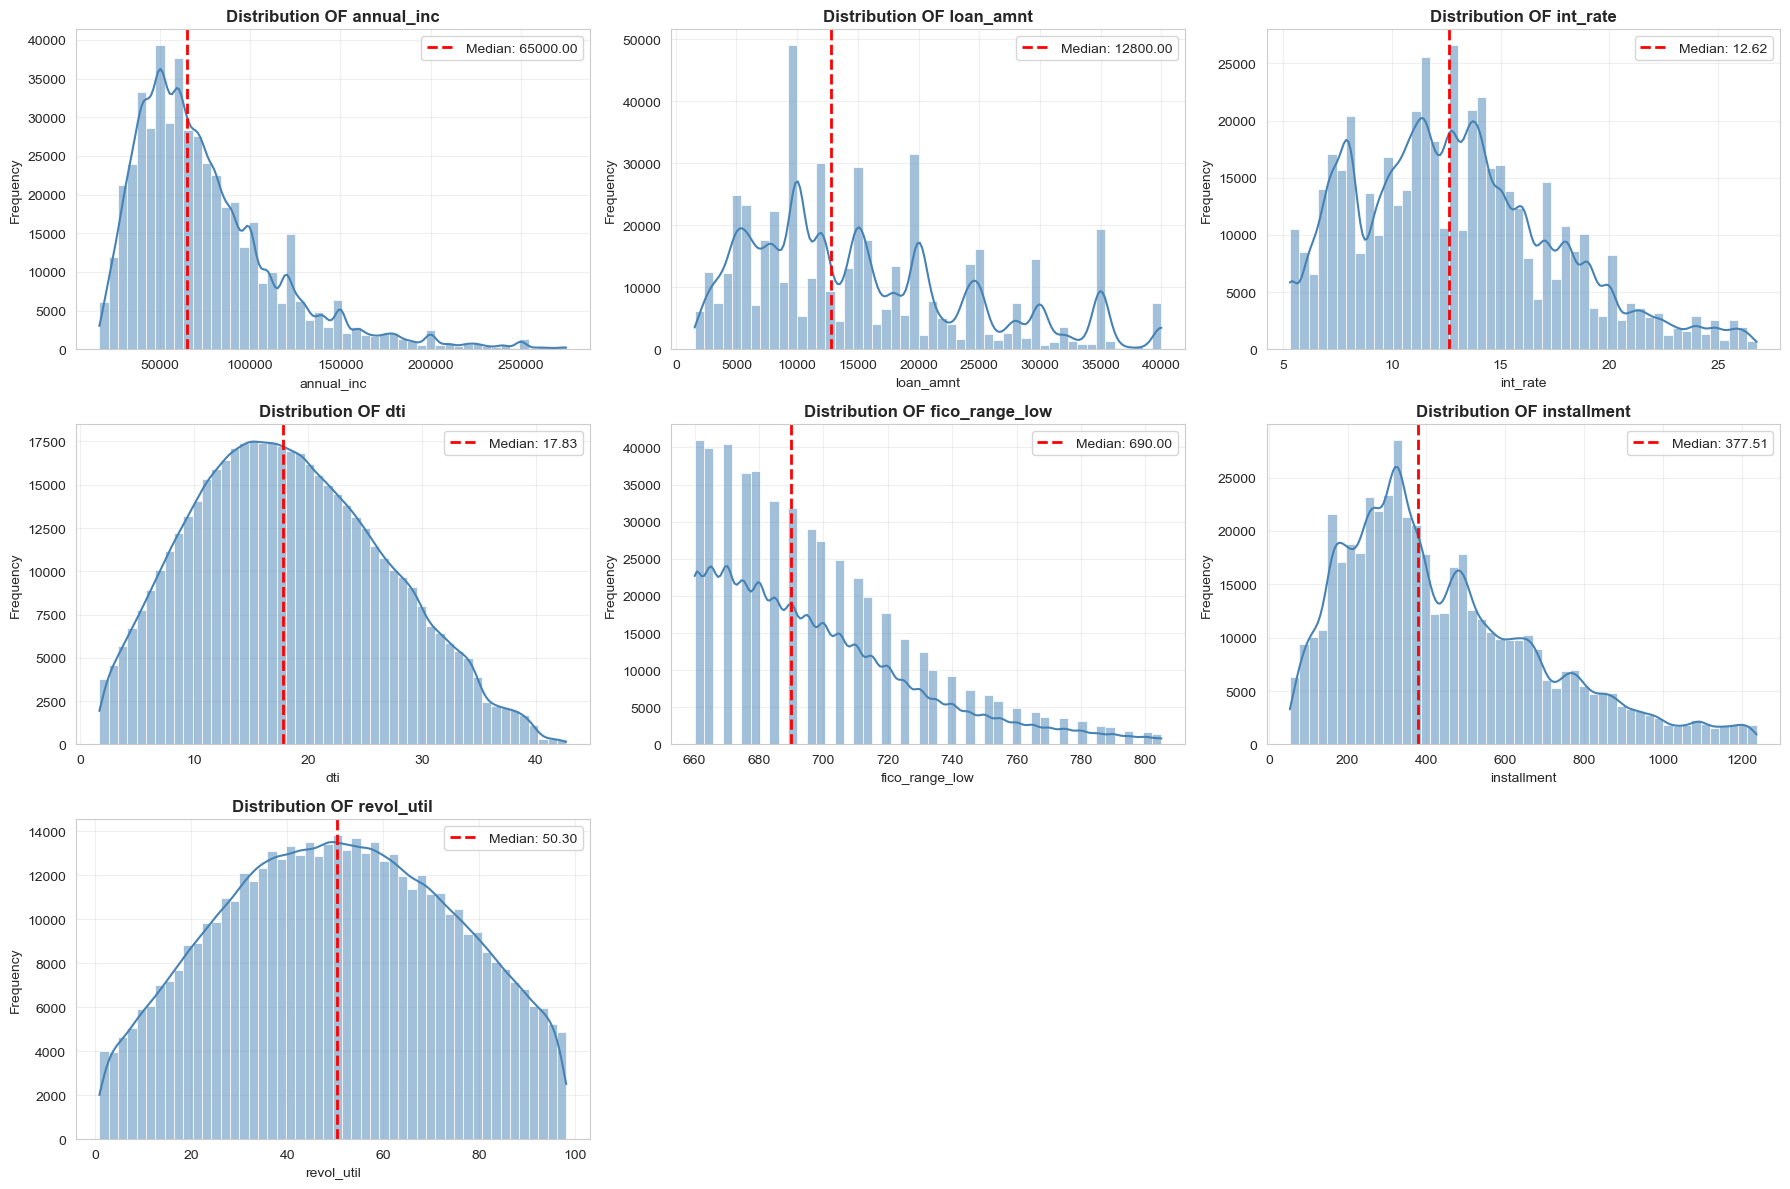

In [39]:
# Distribution plots for numerical features

fig, axes = plt.subplots(3, 3, figsize = (18,12))
axes = axes.flatten()

for i, feature in enumerate(key_num_features):
    ax = axes[i]

    # Remove outliers for better visualization (but keep in data)
    data = df[feature].dropna()
    q1, q99 = data.quantile([0.01, 0.99])
    data_trimmed = data[(data >= q1) & (data <= q99)]

    #ax.hist(data_trimmed, bins = 50, color = 'steelblue', alpha = 0.7, edgecolor = 'black')
    sns.histplot(data_trimmed, kde = True, bins = 50, color = 'steelblue', ax = ax)
    ax.axvline(data.median(), color = 'red', linestyle = '--', linewidth = 2, label = f'Median: {data.median():.2f}')
    ax.set_title(f"Distribution OF {feature}" , fontsize = 12, weight = 'bold')
    ax.set_xlabel(feature, fontsize = 10)
    ax.set_ylabel('Frequency', fontsize = 10)
    ax.legend()
    ax.grid(alpha = 0.3)
    
# Remove extra subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


## Distribution Insights from Numerical Features

| Feature | Distribution Shape | Key Observation |
|--------|-------------------|-----------------|
| annual_inc | Right-skewed | Most borrowers are middle-income with a long tail of high-income outliers |
| loan_amnt | Multi-modal | Peaks at common lending amounts indicating standard loan brackets | 
| int_rate | Multi-modal |Interest rates vary based on borrower risk categories | 
| dti | Approximately normal | Majority of borrowers fall within moderate debt-to-income levels |
| fico_range_low | Right-skewed | Most borrowers have fair to good credit scores | 
| installment | Right-skewed | Monthly payments vary widely depending on loan amount and interest rate |
| revol_util | Near normal | Many borrowers use around half of their available credit | 

## Numerical Features vs Target

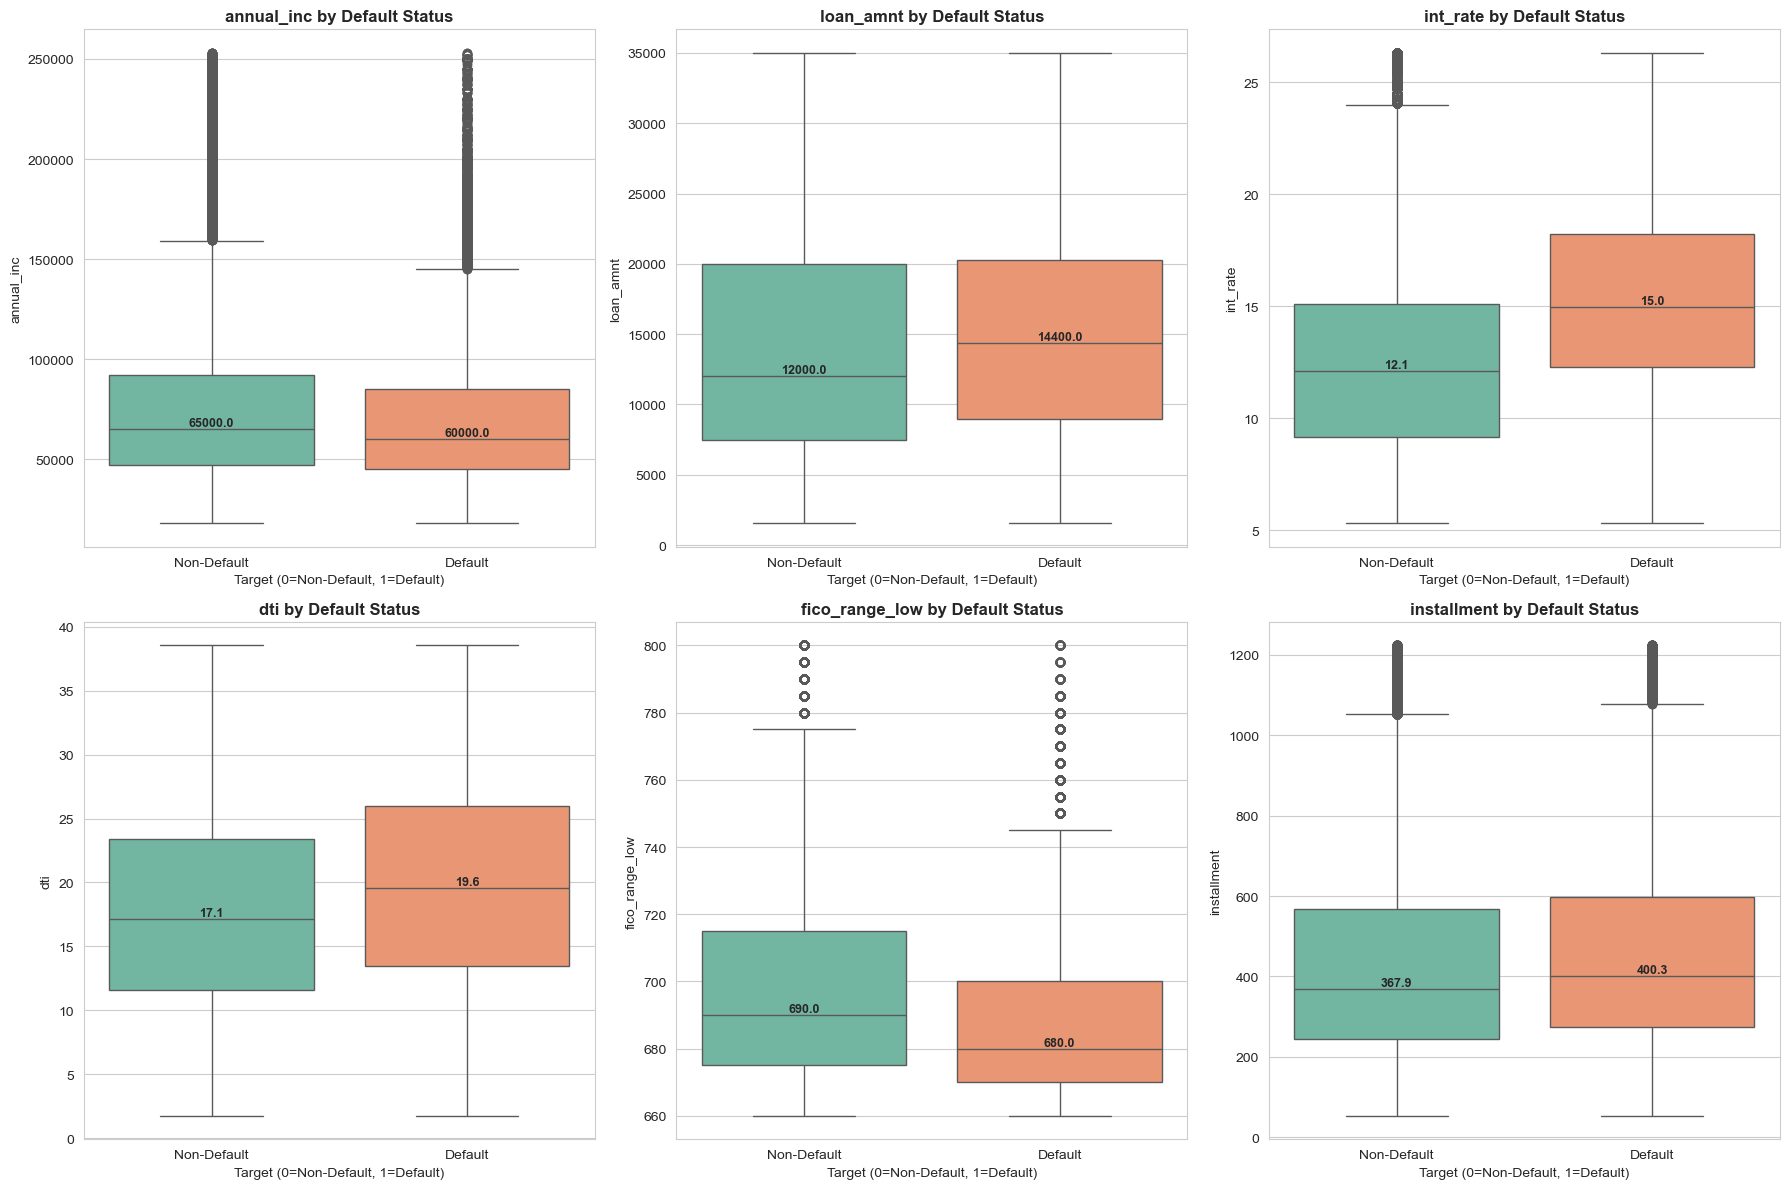

In [40]:
# Box plots: Numerical features by default status

fig, axes = plt.subplots(2,3, figsize = (18,12))
axes = axes.flatten()


for i, feature in enumerate(key_num_features[:6]):
    ax = axes[i]

    # Remove extreme outliers for visualization
    data = df[[feature, 'target']].dropna()
    q1, q99 = data[feature].quantile([0.01, 0.99])
    data = data[(data[feature] >= q1) & (data[feature] <= q99)]

    sns.boxplot(data = data, x = 'target', y = feature, palette = 'Set2', ax= ax)
    ax.set_title(f'{feature} by Default Status', fontsize=12, weight='bold')
    ax.set_xlabel('Target (0=Non-Default, 1=Default)', fontsize = 10)
    ax.set_ylabel(feature, fontsize = 10)
    ax.set_xticklabels(['Non-Default', 'Default'])

    # Add median lines
    medians = data.groupby('target')[feature].median()
    for j, median in enumerate(medians):
        ax.text(j,median, f'{median:.1f}', ha = 'center', va = 'bottom', fontsize = 9, weight = 'bold')

plt.tight_layout()
plt.show()



## Feature vs Default Status Insights

| Feature | Non-Default Median | Default Median | Key Observation | Interpretation |
|--------|--------------------|----------------|----------------|---------------|
| annual_inc | ~65,000 | ~60,000 | Defaulters tend to have slightly lower income | Lower income borrowers may have reduced repayment capacity |
| loan_amnt | ~12,000 | ~14,000 | Defaulters generally take slightly larger loans | Higher loan amounts may increase repayment burden |
| int_rate | ~12.1% | ~15% | Defaulters have noticeably higher interest rates | Higher interest rates reflect higher perceived borrower risk |
| dti | ~17.1 | ~19.6 | Defaulters show higher debt-to-income ratios | Higher financial obligations increase default probability |
| fico_range_low | ~690 | ~680 | Defaulters have slightly lower credit scores | Lower creditworthiness is associated with higher default risk |
| installment | 367 |$400 | Defaulters pay slightly higher monthly installments | Larger monthly payments may increase financial strain |

## Binned Analysis: Default Rate by Feature Quantiles

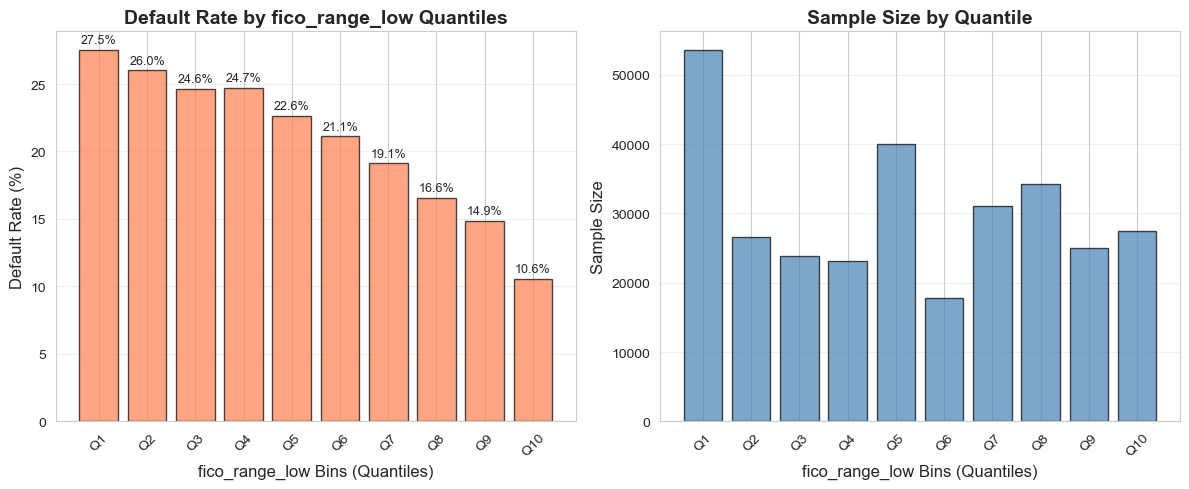

In [41]:
def plot_default_rate_by_bins(df, feature, bins=10, log_transform=False):
    """
    Plot default rate across feature quantiles.
    Useful for understanding non-linear relationships.
    """
    # Create a copy to avoid modifying original
    data = df[[feature, 'target']].copy().dropna()
    
    # Apply log transform if requested
    if log_transform:
        data[f'{feature}_transformed'] = np.log1p(data[feature])
        bin_col = f'{feature}_transformed'
    else:
        bin_col = feature
    
    # Create quantile bins
    data['bin'] = pd.qcut(data[bin_col], q=bins, duplicates='drop')
    
    # Calculate default rate per bin
    default_rate = data.groupby('bin')['target'].agg(['mean', 'count']).reset_index()
    default_rate['default_rate'] = default_rate['mean'] * 100
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    # Bar plot
    plt.subplot(1, 2, 1)
    plt.bar(range(len(default_rate)), default_rate['default_rate'], 
            color='coral', alpha=0.7, edgecolor='black')
    plt.xlabel(f'{feature} Bins (Quantiles)', fontsize=12)
    plt.ylabel('Default Rate (%)', fontsize=12)
    plt.title(f'Default Rate by {feature} Quantiles', fontsize=14, weight='bold')
    plt.xticks(range(len(default_rate)), [f'Q{i+1}' for i in range(len(default_rate))], rotation=45)
    plt.grid(alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, rate in enumerate(default_rate['default_rate']):
        plt.text(i, rate + 0.5, f'{rate:.1f}%', ha='center', fontsize=9)
    
    # Sample size plot
    plt.subplot(1, 2, 2)
    plt.bar(range(len(default_rate)), default_rate['count'], 
            color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel(f'{feature} Bins (Quantiles)', fontsize=12)
    plt.ylabel('Sample Size', fontsize=12)
    plt.title(f'Sample Size by Quantile', fontsize=14, weight='bold')
    plt.xticks(range(len(default_rate)), [f'Q{i+1}' for i in range(len(default_rate))], rotation=45)
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return default_rate

# Example usage

fico_analysis = plot_default_rate_by_bins(df, 'fico_range_low', bins=10)

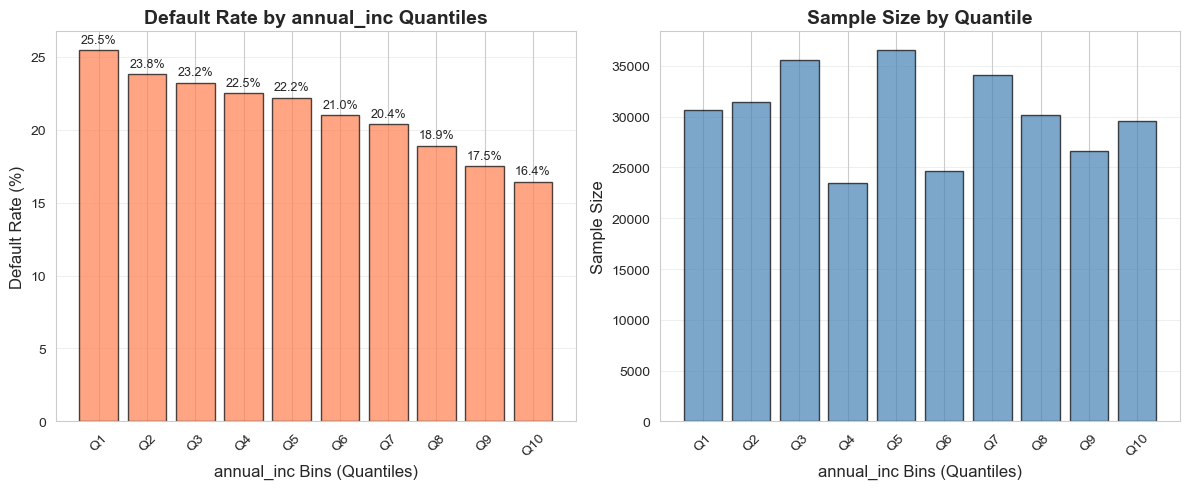

In [42]:
income_analysis = plot_default_rate_by_bins(df, 'annual_inc', bins=10, log_transform=True)

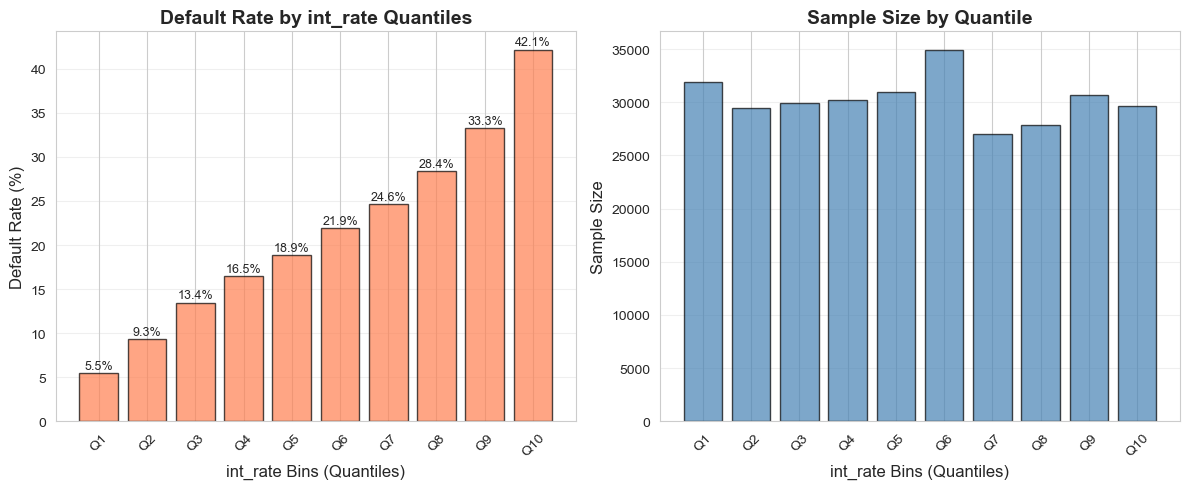

In [43]:
rate_analysis = plot_default_rate_by_bins(df, 'int_rate', bins=10)

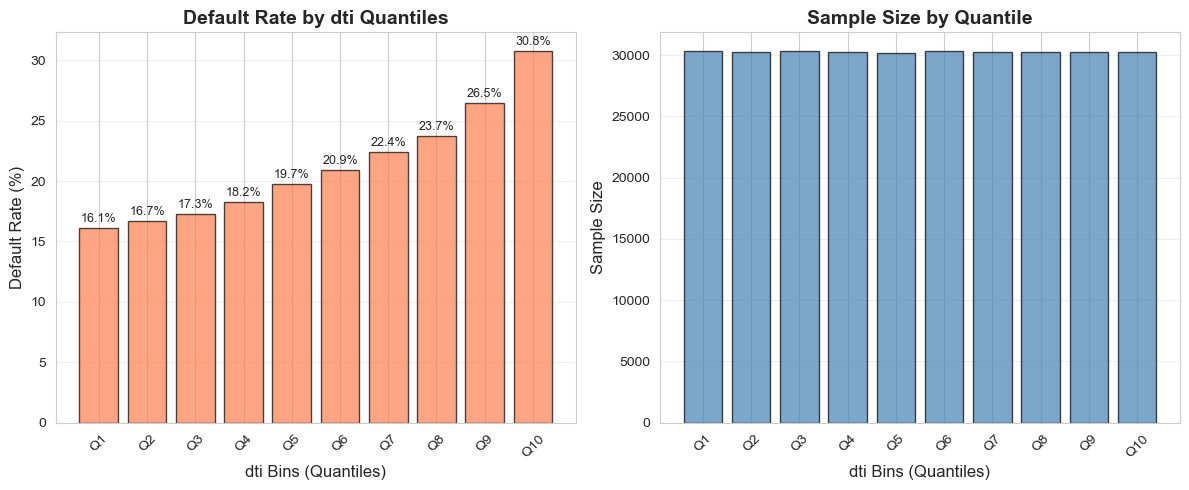

In [44]:
dti_analysis = plot_default_rate_by_bins(df, 'dti', bins=10)

###  Univariate Analysis - Categorical Features

In [45]:
# Select key categorical features
key_cat_features = [
    'grade',
    'sub_grade',
    'term',
    'purpose',
    'home_ownership',
    'verification_status',
    'emp_length'
]

# Check cardinality (number of unique values)
for feature in key_cat_features:
    nunique = df[feature].nunique()
    print(f"{feature:25s} | {nunique:3d} unique values")
   

grade                     |   7 unique values
sub_grade                 |  35 unique values
term                      |   2 unique values
purpose                   |  14 unique values
home_ownership            |   6 unique values
verification_status       |   3 unique values
emp_length                |  11 unique values


In [46]:
def plot_categorical_default_rate(df, feature , max_categories=15):
    """
    Plot default rate by categorical feature.
    """
    
     # Calculate default rate and count
    cat_analysis = df.groupby(feature).agg({'target' : ['mean', 'count']}).reset_index()
    cat_analysis.columns = [feature, 'default_rate', 'count']
    cat_analysis['default_rate'] *= 100

    # Limit to top N categories if too many
    if len(cat_analysis) > max_categories:
        cat_analysis = cat_analysis.nlargest(max_categories, 'count')

    # Sort by default rate
    cat_analysis = cat_analysis.sort_values('default_rate', ascending = False)

    #PLOt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16,8))

    # Default rate plot
    ax1.barh(range(len(cat_analysis)), cat_analysis['default_rate'],color = 'coral')
    ax1.set_yticks(range(len(cat_analysis)))
    ax1.set_yticklabels(cat_analysis[feature], fontsize = 9)
    ax1.set_xlabel('Default Rate (%)', fontsize=12)
    ax1.set_title(f'Default Rate by {feature}', fontsize=14, weight='bold')
    ax1.grid(alpha=0.3, axis='x')

    # Add percentage labels
    for i , rate in enumerate(cat_analysis['default_rate']):
        ax1.text(rate + 0.5, i, f'{rate:.1f}%', va='center', fontsize=9)
    # Distribution plot
    ax2.barh(range(len(cat_analysis)), cat_analysis['count'], color='steelblue', alpha=0.7)
    ax2.set_yticks(range(len(cat_analysis)))
    ax2.set_yticklabels(cat_analysis[feature], fontsize=9)
    ax2.set_xlabel('Count', fontsize=12)
    ax2.set_title(f'Sample Size by {feature}', fontsize=14, weight='bold')
    ax2.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    return cat_analysis
        

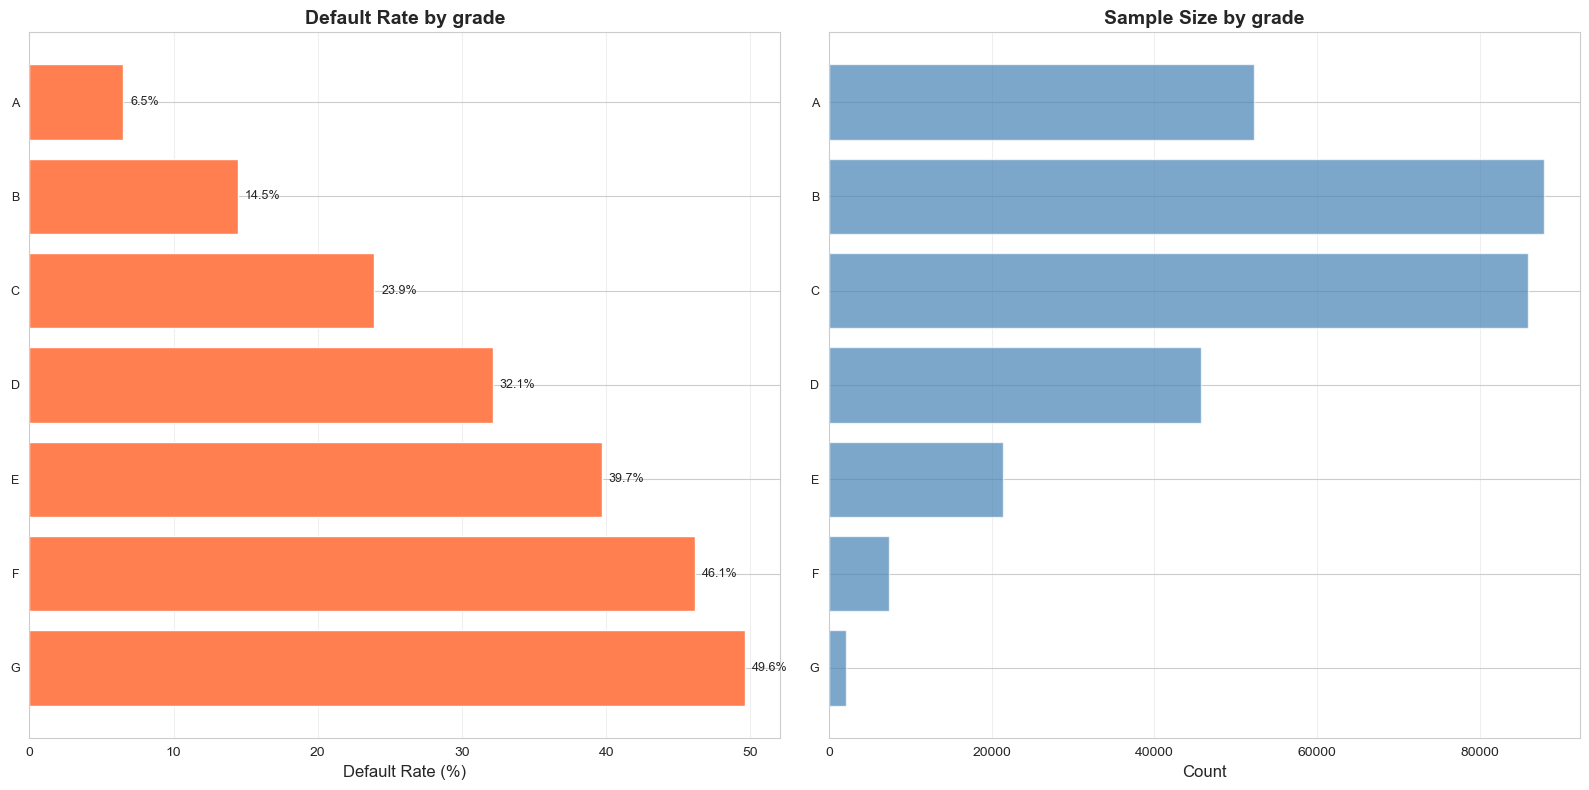

In [47]:
grade_analysis = plot_categorical_default_rate(df, 'grade')

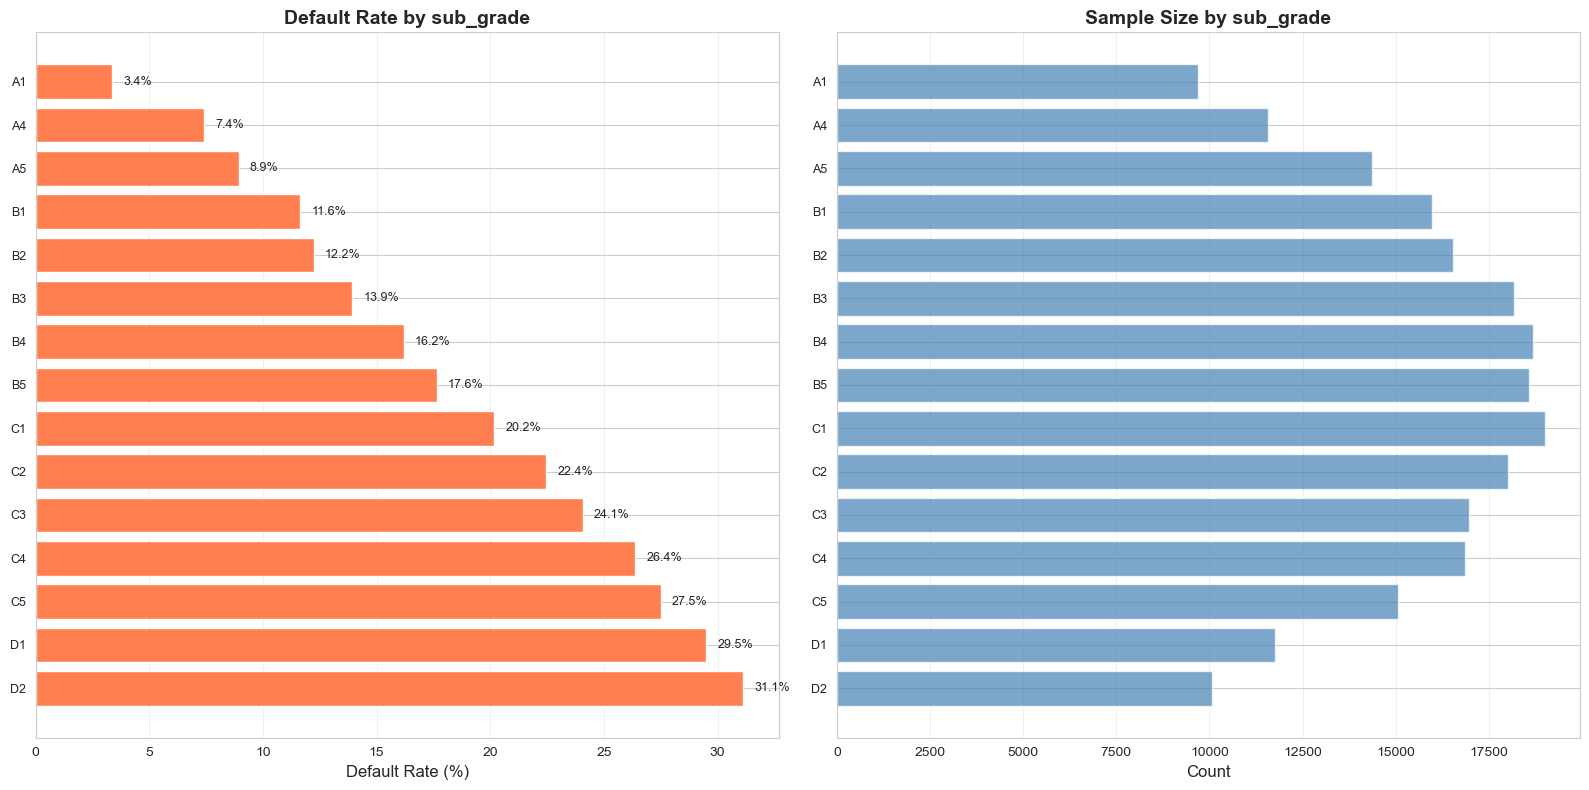

In [48]:
grade_analysis = plot_categorical_default_rate(df, 'sub_grade')

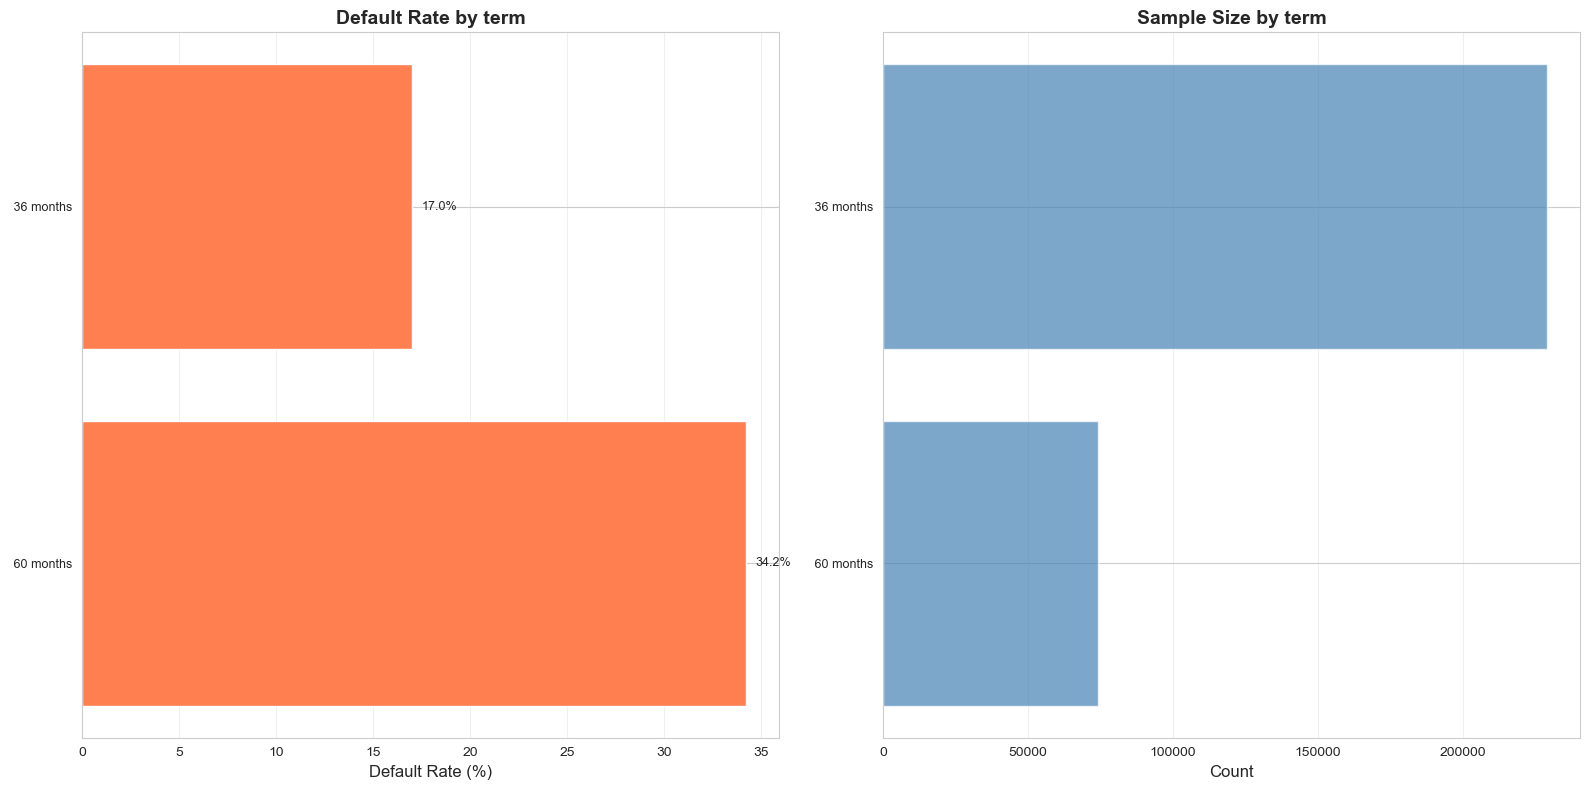

In [49]:
term_analysis = plot_categorical_default_rate(df, 'term')

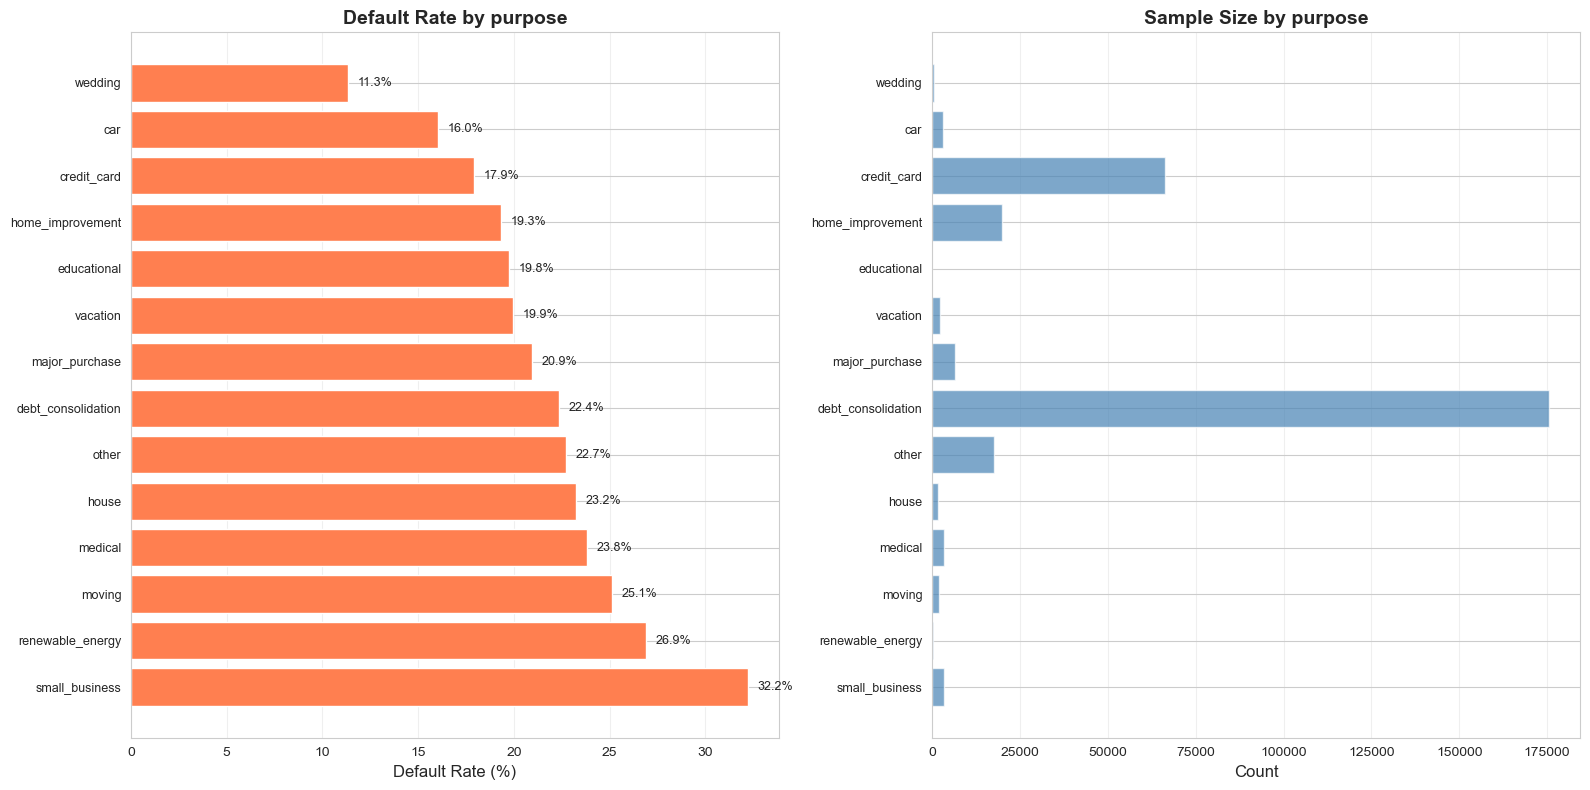

In [50]:
purpose_analysis = plot_categorical_default_rate(df, 'purpose')

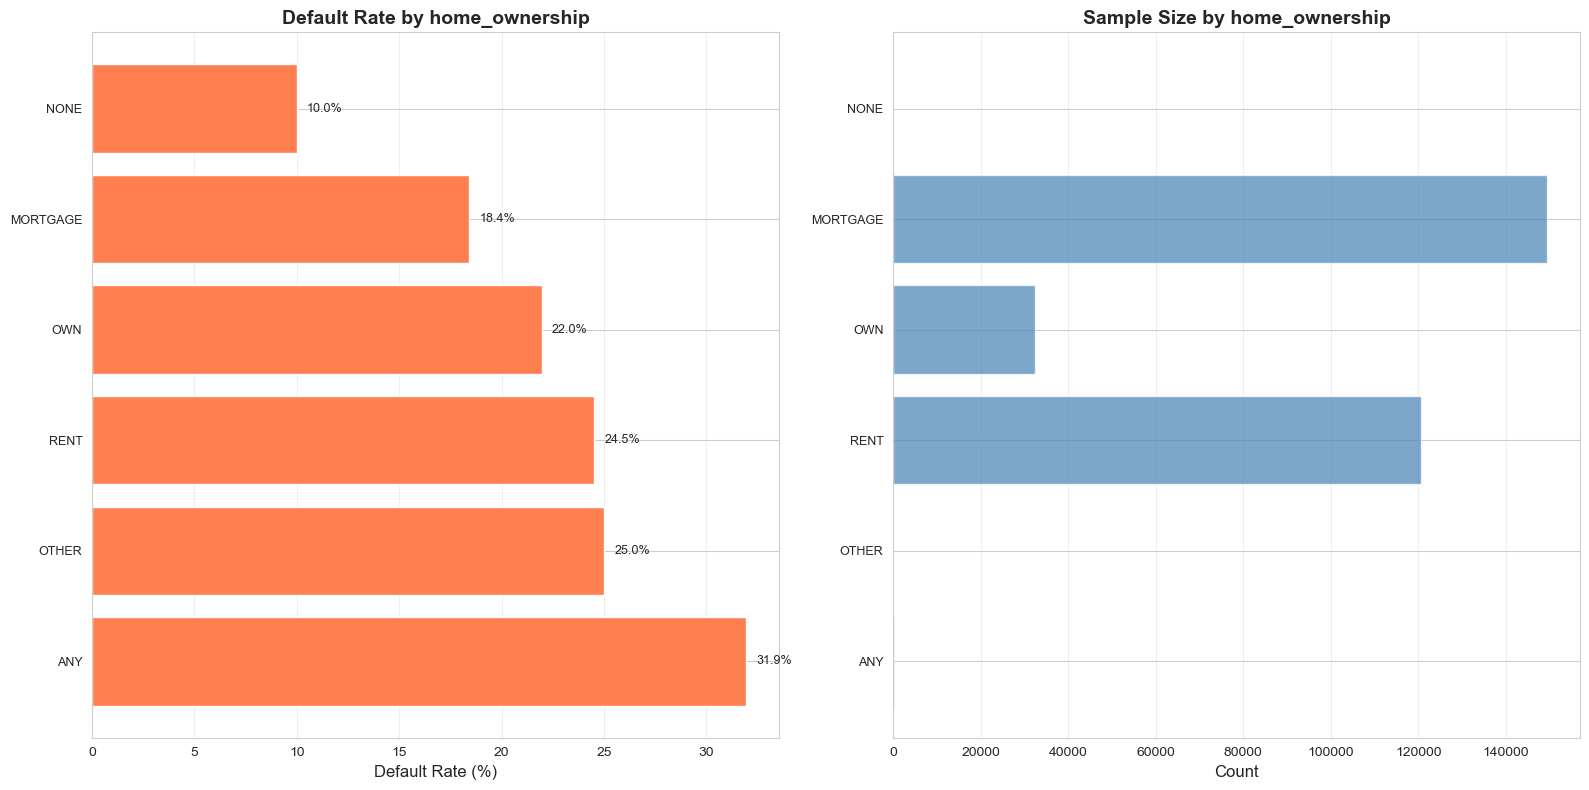

In [51]:
home_analysis = plot_categorical_default_rate(df, 'home_ownership')

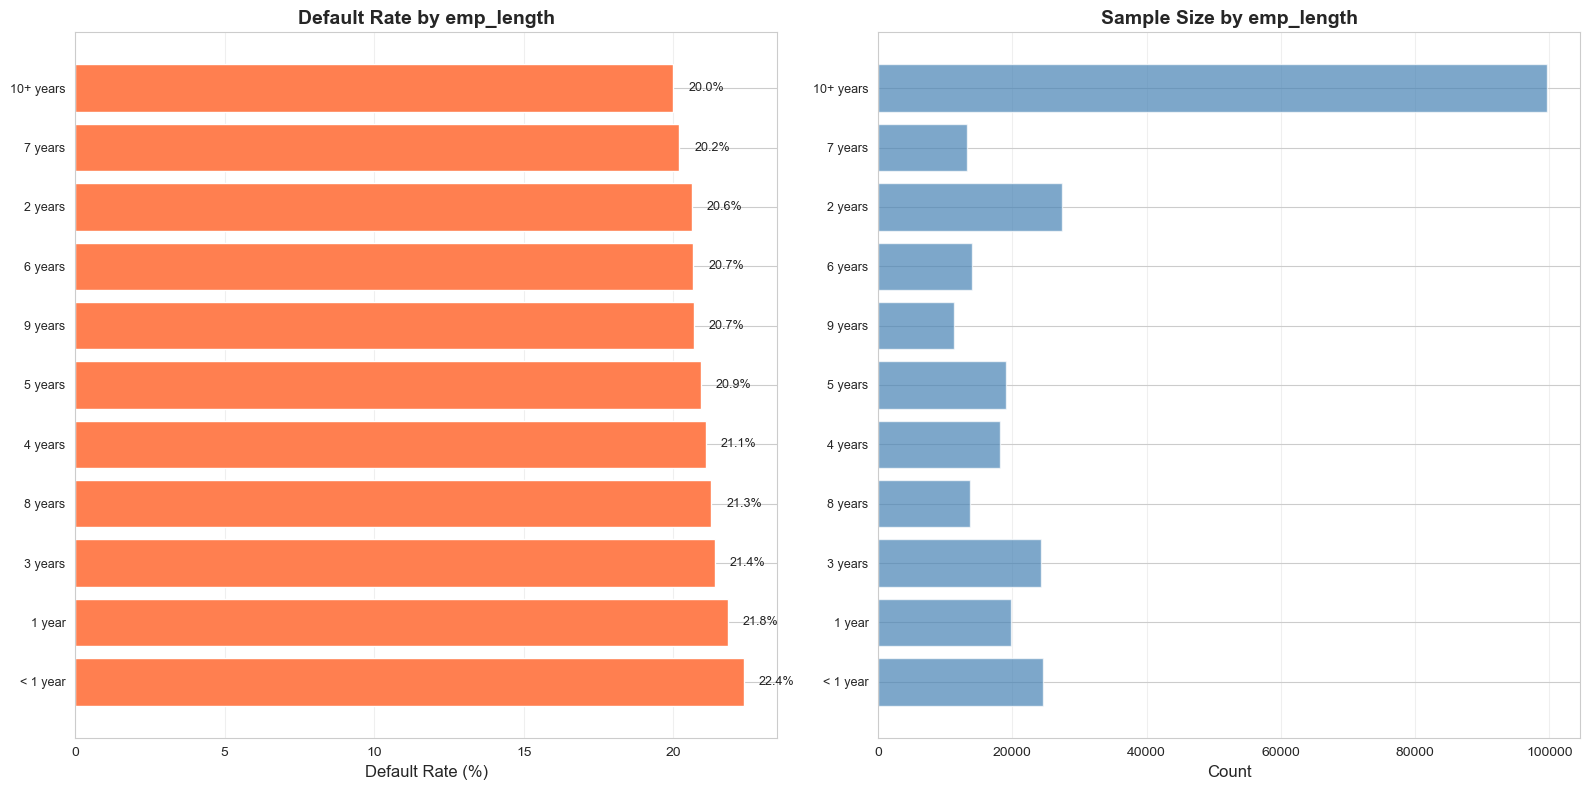

In [52]:
emp_analysis = plot_categorical_default_rate(df, 'emp_length')

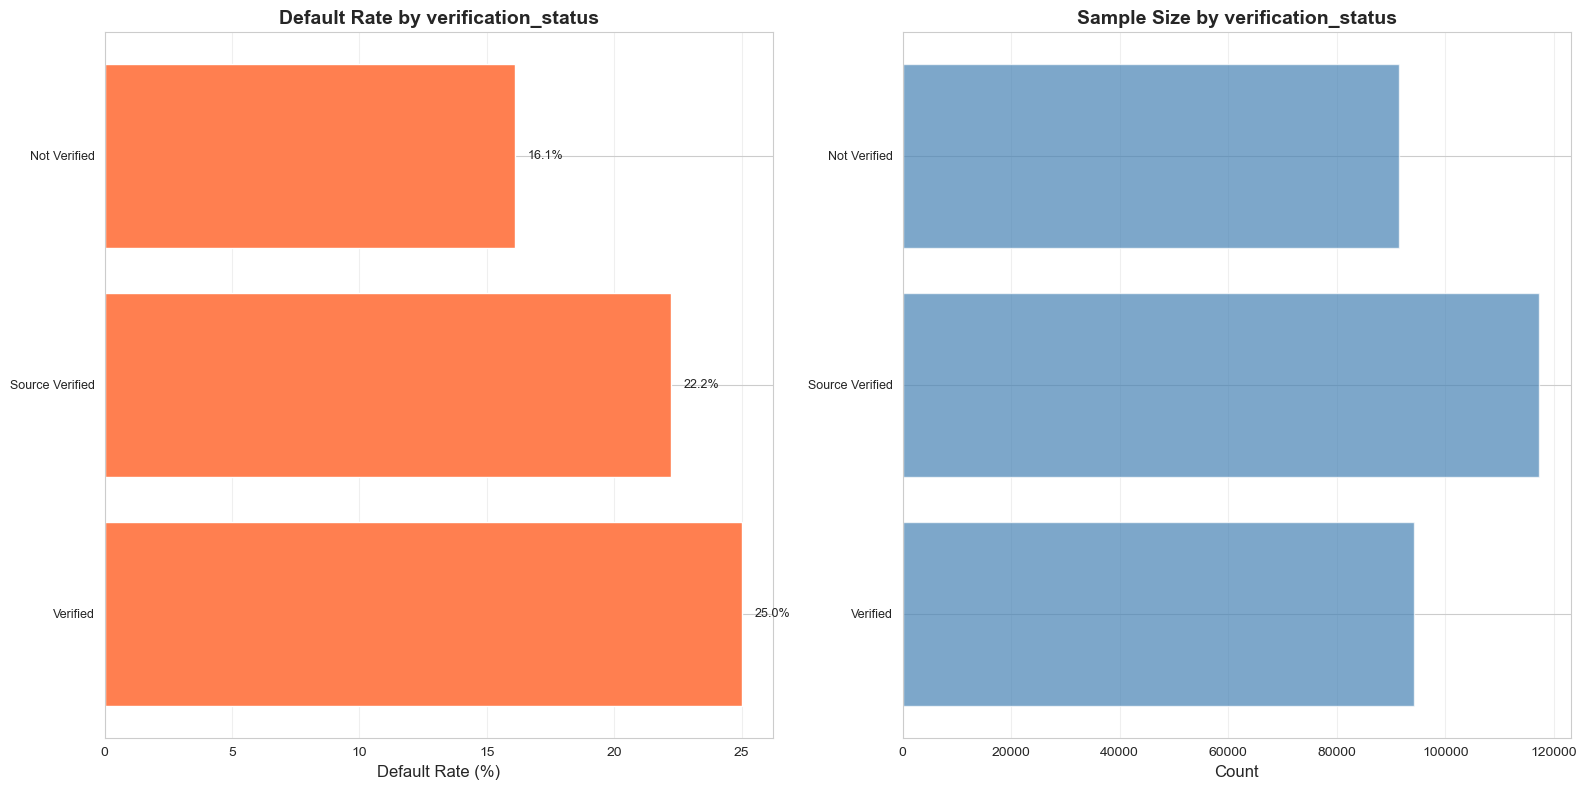

In [53]:
emp_analysis = plot_categorical_default_rate(df, 'verification_status')

### Key Insights from Categorical Analysis

| Feature | Relationship with Default | Business Insight |
|---------|---------------------------|------------------|
| **grade** | Strong gradient (A→G) | LC's risk grading is highly predictive of default |
| **term** | 60 months > 36 months | Longer commitment → higher default risk |
| **purpose** | Small business highest | Business loans riskier than personal/consolidation |
| **home_ownership** | Rent > Mortgage > Own | Homeownership indicates financial stability |
| **emp_length** | Weak signal | Employment duration less predictive than expected |
| **verification_status** | Verified slightly higher | Paradox: verified borrowers may be riskier (LC verifies risky cases) |

###  Correlation and Multicollinearity Analysis

**Purpose:** Identify highly correlated features that may cause multicollinearity in linear models.

**Note:** Final decisions on feature removal will be made during feature engineering based on model type.

In [54]:
# Select numerical columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Remove leakage columns from correlation analysis
leakage_numeric = [col for col in all_leakage_candidates if col in numeric_df.columns]
clean_numeric = numeric_df.drop(columns=leakage_numeric + ['target'])

print(f"Analyzing correlations for {clean_numeric.shape[1]} numerical features (leakage removed)")

Analyzing correlations for 71 numerical features (leakage removed)


In [55]:
# Compute correlation matrix
corr_matrix = clean_numeric.corr()

# Find highly correlated pairs (>0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\nHighly Correlated Feature Pairs (|r| > 0.8): {len(high_corr_pairs)}")
if high_corr_pairs:
    print("\nTop 10 Correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:25s} <-> {feat2:25s} | r = {corr:.3f}")


Highly Correlated Feature Pairs (|r| > 0.8): 25

Top 10 Correlations:
  fico_range_low            <-> fico_range_high           | r = 1.000
  out_prncp                 <-> out_prncp_inv             | r = 1.000
  loan_amnt                 <-> funded_amnt               | r = 1.000
  funded_amnt               <-> funded_amnt_inv           | r = 0.999
  loan_amnt                 <-> funded_amnt_inv           | r = 0.999
  open_acc                  <-> num_sats                  | r = 0.999
  num_actv_rev_tl           <-> num_rev_tl_bal_gt_0       | r = 0.984
  tot_cur_bal               <-> tot_hi_cred_lim           | r = 0.977
  funded_amnt               <-> installment               | r = 0.946
  loan_amnt                 <-> installment               | r = 0.946


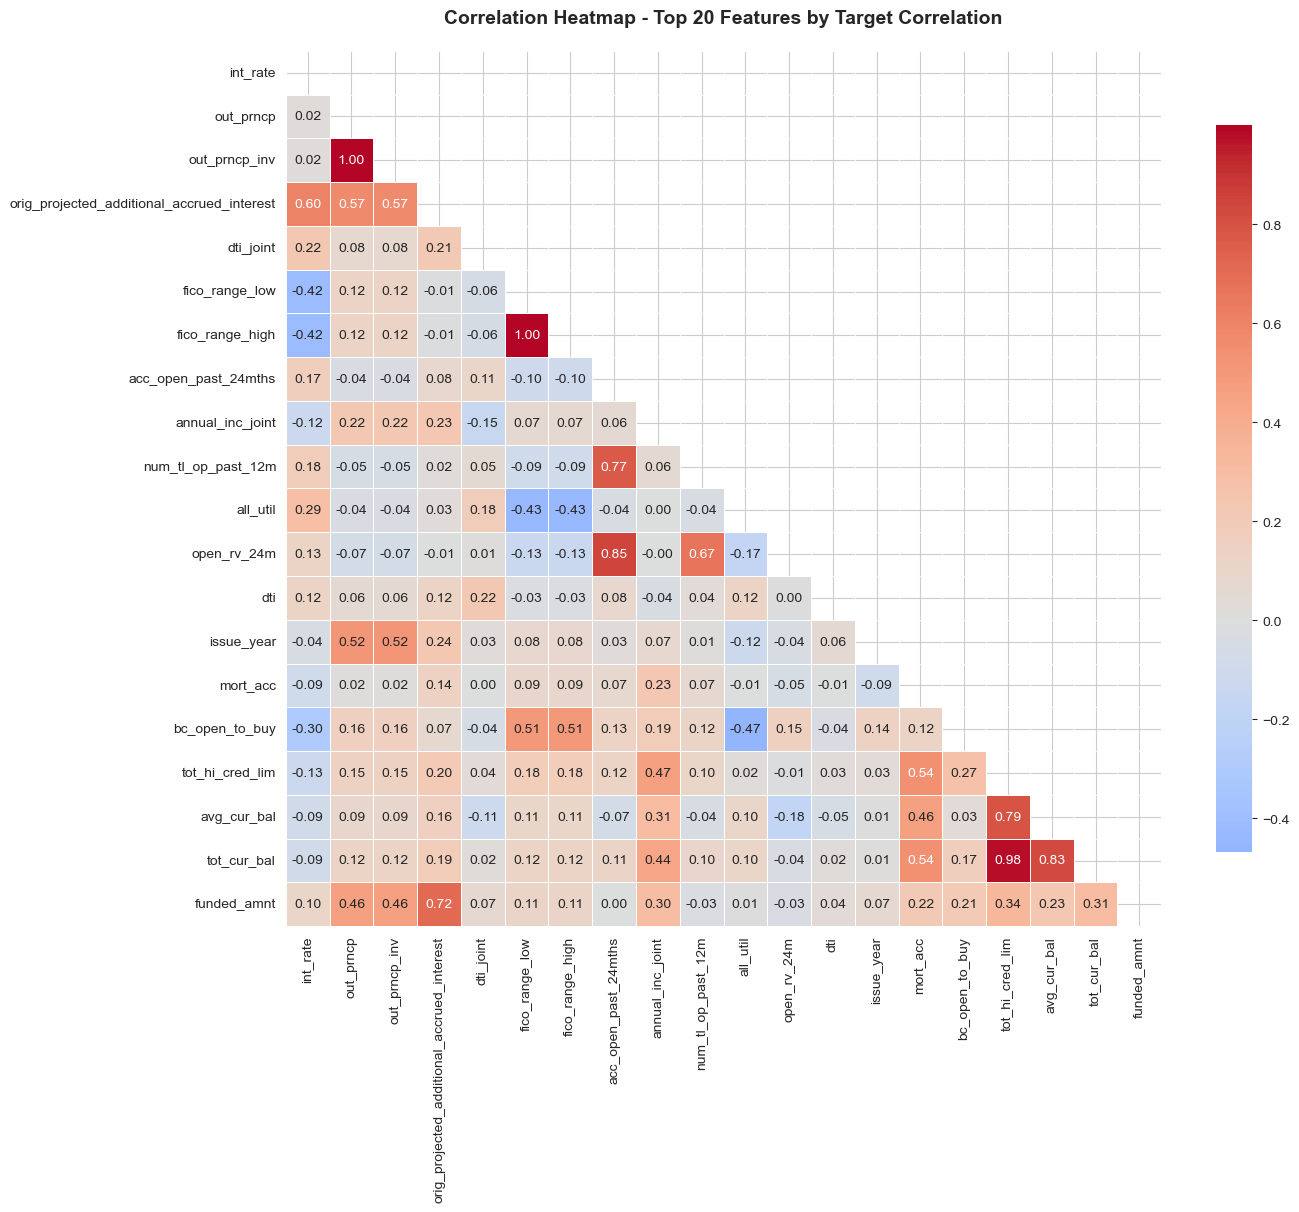

In [56]:
# Visualize correlation matrix (top features only for readability)
# Focus on features with highest correlation to target

# Get top 20 features by correlation with target
target_corr = df[clean_numeric.columns.tolist() + ['target']].corr()['target'].abs().sort_values(ascending=False)
top_features = target_corr.head(21).index.tolist()  # +1 for target itself
top_features.remove('target')
top_features = top_features[:20]

# Create correlation matrix for top features
top_corr = df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(top_corr, dtype=bool))  # Mask upper triangle
sns.heatmap(
    top_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap - Top 20 Features by Target Correlation', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

In [57]:
print(df['policy_code'].value_counts())

policy_code
1.0    499608
Name: count, dtype: int64


In [58]:
FINAL_DROP_LIST = [

    # === IDENTIFIERS ===
    'id',
    'member_id',
    'url',
    'policy_code',
    
    # === REDUNDANT FEATURES — High correlation ===
    'funded_amnt',
    'funded_amnt_inv',
    'num_sats',
    'num_rev_tl_bal_gt_0',

    # === POST-LOAN PAYMENTS & RECOVERY — Leakage ===
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',

    # === POST-LOAN DATES — Leakage ===
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',

    # === POST-LOAN FICO — Leakage ===
    'last_fico_range_high',
    'last_fico_range_low',

    # === SETTLEMENT — Leakage ===
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',

    # === HARDSHIP — Leakage ===
    'hardship_flag',
    'hardship_type',
    'hardship_reason',
    'hardship_status',
    'hardship_start_date',
    'hardship_end_date',
    'payment_plan_start_date',
    'hardship_dpd',
    'hardship_loan_status',
    'hardship_payoff_balance_amount',
    'hardship_amount',
    'orig_projected_additional_accrued_interest',
    'hardship_last_payment_amount',
    'hardship_length',
    'deferral_term',

    # === PAYMENT PLAN — Leakage ===
    'pymnt_plan',

    # === SECONDARY APPLICANT — High missingness ===
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'revol_bal_joint',
    'sec_app_num_rev_accts',
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_open_acc',
    'sec_app_revol_util',
    'sec_app_open_act_il',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',

    # === HIGH MISSING / UNSTRUCTURED ===
    'desc'
]

### Why We Are Dropping These Features

---

#### 1. Identifiers
`id`, `member_id`, `url`

These are internal identifiers or links. They do not represent borrower credit risk and should not be used as predictive features.

---

#### 2. Zero Variance
`policy_code`

This column contains only one value in the analyzed data. A feature that does not vary cannot help separate high-risk and low-risk loans.

---

#### 3. Redundant Features
`funded_amnt`, `funded_amnt_inv`, `num_sats`, `num_rev_tl_bal_gt_0`

These fields are near-duplicates or highly correlated with other retained fields. Redundant fields can add noise, inflate model complexity, and make interpretation harder.

---

#### 4. Post-Loan Payments and Recovery
`out_prncp`, `total_pymnt`, `recoveries`, `collection_recovery_fee`, `last_pymnt_amnt`, and related fields

These values are created after the loan is issued and after repayment begins. An investor would not know them at listing time. Keeping them would leak the outcome.

---

#### 5. Post-Loan Dates
`last_pymnt_d`, `next_pymnt_d`, `last_credit_pull_d`

These dates are created during the loan lifecycle, not before investment. They are unavailable for a new loan listing and should be removed.

---

#### 6. Post-Loan FICO Scores
`last_fico_range_high`, `last_fico_range_low`

These are updated after loan issuance. They may reflect deterioration caused by delinquency, so they are outcome-contaminated.

---

#### 7. Settlement and Hardship Fields
Settlement and hardship fields are created only after repayment difficulty occurs. They are consequences of distress, not pre-investment signals.

---

#### 8. Payment Plan
`pymnt_plan`

A payment plan is associated with loan servicing and borrower difficulty after origination, so it is not safe for listing-time prediction.

---

#### 9. Secondary Applicant Fields
Joint/secondary applicant fields are not necessarily leakage. They are excluded from v1 because coverage is sparse and optional. They can be revisited later as a separate model variant if joint applications are important.

---

#### 10. High-Missing or Unstructured Text
`desc`, `title`, and similar free-text fields may contain useful information but require NLP-specific handling. They are excluded from the first structured-data model to keep the pipeline stable and interpretable.


In [59]:
# Check which columns in  list actually exist in df
missing_from_df = [col for col in FINAL_DROP_LIST if col not in df.columns]
print(f"Columns in drop list but NOT in df ({len(missing_from_df)}):")
print(missing_from_df)

Columns in drop list but NOT in df (0):
[]


In [60]:
print(f"Total flagged for removal       : {len(FINAL_DROP_LIST)}")
print(f"Estimated features remaining    : {df.shape[1] - len(FINAL_DROP_LIST)}")


Total flagged for removal       : 63
Estimated features remaining    : 90


### Top 5 Drivers of Default Risk

These features consistently show the strongest relationship with loan default in this dataset. Each captures a different dimension of borrower risk and aligns with real-world lending practices.

---

**1. Loan Grade (and Associated Interest Rate)**

**Observation:**
Default rates increase monotonically from ~5% (Grade A) to ~35% (Grade G). Higher grades are also associated with significantly higher interest rates.

**Why it happens:**
Loan grade acts as a strong proxy for LendingClub’s internal risk assessment, combining borrower characteristics such as FICO score, DTI, income, and loan amount into a single risk tier. Borrowers in lower grades (E–G) are inherently riskier.

The higher interest rate assigned to these borrowers compensates for this risk, but also increases their repayment burden, further raising the likelihood of default.

---

**2. FICO Score**

**Observation:**
Default risk declines sharply above a FICO score of ~720. Borrowers below ~580 show significantly higher default rates.

**Why it happens:**
FICO score summarizes a borrower’s credit history, including repayment behavior, utilization, credit age, and past delinquencies. Lower scores indicate poor historical repayment performance, while higher scores reflect consistent credit discipline.

The sharp drop in risk above ~720 indicates a transition to reliably stable repayment behavior, rather than a gradual improvement.

---

**3. Debt-to-Income Ratio (DTI)**

**Observation:**
Default risk increases as DTI rises, with a noticeable acceleration beyond 35–40%.

**Why it happens:**
DTI measures the borrower’s existing debt burden before the new loan is added. A higher DTI means a larger portion of income is already committed, leaving limited capacity to absorb additional obligations.

The new loan further increases financial pressure, which is better captured by the derived feature pti_ratio (installment / monthly income), representing the true repayment burden.

---

**4. Revolving Credit Utilization**

**Observation:**
Default risk increases significantly when utilization exceeds ~80%, with noticeable risk elevation starting around 50–60%.

**Why it happens:**
High utilization indicates that the borrower is heavily reliant on credit and has limited available credit capacity. At very high levels, borrowers may be using credit to sustain ongoing expenses rather than discretionary use.

This makes utilization one of the most immediate indicators of financial stress and reduced liquidity, increasing the probability of default.

---

**5. Recent Delinquency History (mths_since_last_delinq)**

**Observation:**
Borrowers with recent delinquencies show significantly higher default rates compared to those with no history of missed payments. Even a single delinquency materially increases risk.

**Why it happens:**
Past repayment behavior is one of the strongest predictors of future behavior. A delinquency indicates that the borrower has previously failed to meet obligations under financial stress.

Additionally, the high missingness in mths_since_last_delinq is itself informative — a missing value typically indicates no prior delinquency, which is a strong positive signal of creditworthiness.

---


### **EDA Summary - LendingClub Investor Loan Risk Selector**

---

#### Dataset Overview

- LendingClub accepted-loan data spans 2007-2018.
- The notebook uses an initial 500,000-row sample for EDA.
- Because the sample is taken from the start of the CSV, it is temporally biased toward older loan vintages.
- Final modeling should rely on temporal splits from the full processed dataset.

---

#### Business Objective

The project is framed as an **investor-style LendingClub loan selector**.

The model should help investors rank listed loans by serious delinquency/default-like risk before choosing whether to invest.

Because this is an investor-style use case, listing-time LendingClub fields such as `grade`, `sub_grade`, and `int_rate` are allowed. Post-loan servicing and repayment fields are not allowed.

---

#### Target Variable Definition

- `Fully Paid` is labeled as non-default.
- `Charged Off`, `Default`, and `Late (31-120 days)` are labeled as serious delinquency/default-like outcomes.
- `Current`, `In Grace Period`, and `Late (16-30 days)` are excluded because their final outcome is uncertain.
- The target should be described as `serious_delinquency_or_default`, not strict regulatory default.

---

#### Missing Value Analysis

- Some missingness is informative, such as missing delinquency-history fields indicating no prior event.
- Some missingness is schema-driven, especially modern tradeline fields that are mostly unavailable in older years and more available after 2015.
- Schema-driven missingness should be handled separately from borrower-level missingness.

---

#### Leakage Detection

- Post-loan payment, recovery, hardship, settlement, last-payment, last-credit-pull, and last-FICO fields are leakage and must be removed.
- Secondary applicant fields are not necessarily leakage; they are excluded from v1 mainly because of sparse optional coverage.
- LendingClub listing fields such as `sub_grade` and `int_rate` are allowed for investor-style modeling.

---

#### Temporal and Schema Drift

- Default-like rates and feature availability should be checked by `issue_year`.
- Tradeline features such as `open_acc_6m`, `open_rv_12m`, `inq_fi`, and `all_util` may be unsuitable for a long-history 2007-2015 training split because they are mostly missing historically.
- Two modeling strategies are recommended:
  1. Stable long-history model with schema-drift tradeline columns dropped.
  2. Modern-schema model using 2016 train, 2017 validation, and 2018 test with tradeline columns included.

---

#### Planned Feature Engineering

| New Feature | Logic | Purpose |
|---|---|---|
| `fico_score` | Average of low and high FICO bounds | Single clean credit score |
| `pti_ratio` | `installment / (annual_inc / 12)` | Monthly payment burden relative to income |
| `loan_to_income` | `loan_amnt / annual_inc` | Total loan size relative to income |
| `overall_util` | `tot_cur_bal / (tot_hi_cred_lim + 1)` | Holistic utilization proxy |
| `credit_age_yrs` | `issue_d - earliest_cr_line` in years | Length of credit history |
| missingness flags | Binary flags for meaningful missing credit events | Preserve missingness signal |

---

#### Next Step

The feature engineering notebook should convert these EDA decisions into a reproducible preprocessing design, with separate handling for stable long-history features and modern-schema tradeline features.
